# Log Anomaly Detection — Drain3 + DistilBERT + VAE

Pipeline deteksi anomali log dengan:
1. **Parsing** log mentah menggunakan Drain3
2. **Windowing** — Sliding Window (BGL/Thunderbird) atau Block ID (HDFS)
3. **Embedding** tiap sekuens menggunakan DistilBERT + Mean Pooling
4. **Split** Train / Validasi / Uji dengan rasio yang dapat dikonfigurasi
5. **Hyperparameter Search** — Optuna: latent_dim, vae_batch_size, beta, learning_rate
6. **Training VAE** dengan konfigurasi terbaik + metrik waktu latih per epoch
7. **Deteksi Anomali** threshold Persentil & EVT/GPD + metrik waktu inferensi
8. **Evaluasi** terpisah Train/Val/Uji
9. **Penyimpanan Artefak** per konfigurasi hyperparameter

**Dataset:** BGL, Thunderbird, HDFS

> **Versi Kaggle** — notebook ini telah disesuaikan agar berjalan optimal di Kaggle Notebooks (GPU T4/P100, path `/kaggle/input` & `/kaggle/working`, instalasi paket yang sudah disesuaikan dengan environment Kaggle).

## 1. Instalasi Dependensi

In [1]:
!pip install --upgrade pip -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.8 MB/s eta 0:00:0000:0100:01


In [2]:
print('Melewati instalasi ulang torch — menggunakan torch bawaan Kaggle.')

Melewati instalasi ulang torch — menggunakan torch bawaan Kaggle.


In [3]:
%pip install -q drain3 optuna fvcore
%pip install -q -U transformers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Import Library

In [4]:
import os, time, re, json, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizer, DistilBertModel
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig
from scipy.stats import genpareto

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score,
    precision_score, recall_score, f1_score, accuracy_score, roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

try:
    from fvcore.nn import FlopCountAnalysis
    FVCORE_AVAILABLE = True
except ImportError:
    FVCORE_AVAILABLE = False
    print('[WARN] fvcore tidak tersedia — FLOPs akan diestimasi manual.')

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [5]:
print('Versi Torch     :', torch.__version__)
print('CUDA tersedia   :', torch.cuda.is_available())
print('Versi CUDA      :', torch.version.cuda)
if torch.cuda.is_available():
    print('Nama GPU        :', torch.cuda.get_device_name(0))
else:
    print('\n[PERINGATAN] GPU tidak terdeteksi!')
    print('Di Kaggle: buka panel kanan (Settings) -> Accelerator -> pilih GPU T4 x2 / P100, lalu Save & restart session.')

Versi Torch     : 2.10.0+cu128
CUDA tersedia   : True
Versi CUDA      : 12.8
Nama GPU        : Tesla T4


In [6]:
!python --version

Python 3.12.13


## 3. Konfigurasi

In [ ]:
import os as _os
IS_KAGGLE = _os.path.exists("/kaggle/input")

KAGGLE_DATASET_DIR = "/kaggle/input/datasets/shutterisland/log-system-detection-anomaly"

CONFIG = {
    "dataset_name"    : "BGL",
    "log_file"        : f"{KAGGLE_DATASET_DIR}/BGL.log" if IS_KAGGLE else "../Dataset/BGL.log",
    "max_lines"       : None,
    "hdfs_label_file" : f"{KAGGLE_DATASET_DIR}/anomaly_label.csv" if IS_KAGGLE else "../Dataset/anomaly_label.csv",
    "window_size"     : 20,
    "bert_model"      : "distilbert-base-uncased",
    "bert_max_length" : 512,
    "bert_batch_size" : 32,
    "train_ratio"     : 0.80,
    "val_ratio"       : 0.50,
    "n_train_normal"  : None,
    "latent_dim"      : 64,
    "hidden_dims"     : [512, 256, 128],
    "vae_epochs"      : 50,
    "vae_batch_size"  : 128,
    "learning_rate"   : 0.00083716,
    "beta"            : 0.126379,
    "hp_search_enabled"  : True,
    "hp_n_trials"        : 30,
    "hp_epochs_per_trial": 15,
    "hp_search_frac"     : 1,
    "hp_search_space"    : {
        "latent_dim"     : [16, 32, 64, 128],
        "vae_batch_size" : [16, 32, 64, 128, 256],
        "beta"           : (0.1, 5.0),
        "learning_rate"  : (1e-4, 1e-2),
    },
    "threshold_percentiles": [90,95,99],
    "seed"       : 42,
    "output_dir" : "/kaggle/working/outputs" if IS_KAGGLE else "./outputs",
}

assert 0 < CONFIG["train_ratio"] < 1.0, "train_ratio harus di rentang (0, 1)"
assert 0 < CONFIG["val_ratio"] < 1.0, "val_ratio harus di rentang (0, 1)"
assert 0 < CONFIG["hp_search_frac"] <= 1.0, "hp_search_frac harus di rentang (0, 1]"
_os.makedirs(CONFIG["output_dir"], exist_ok=True)
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print(f"Berjalan di Kaggle : {IS_KAGGLE}")
print("Konfigurasi berhasil dimuat.")
print(f"  log_file        : {CONFIG['log_file']}")
print(f"  hdfs_label_file : {CONFIG['hdfs_label_file']}")
print(f"  output_dir      : {CONFIG['output_dir']}")
print("  Skema split: Train & Val = HANYA data NORMAL | Uji = sisa normal + SELURUH anomali")
if CONFIG["n_train_normal"] is None:
    print(f"  train_ratio (dari total normal) = {CONFIG['train_ratio']:.0%} -> dipakai sebagai default n_train_normal")
else:
    print(f"  n_train_normal diset eksplisit di CONFIG = {CONFIG['n_train_normal']:,}")
print(f"  val_ratio (dari sisa normal setelah train) = {CONFIG['val_ratio']:.0%}")
print(f"  HP-search data fraction: {CONFIG['hp_search_frac']:.0%} dari data latih normal")

if IS_KAGGLE and not _os.path.exists(CONFIG["log_file"]):
    print("\n[PERINGATAN] File log tidak ditemukan di path di atas.")
    print("Isi folder /kaggle/input yang tersedia saat ini:")
    for d in _os.listdir("/kaggle/input"):
        print(" -", d)
    print("Perbarui KAGGLE_DATASET_DIR di atas agar sesuai, lalu jalankan ulang sel ini.")


Berjalan di Kaggle : True
Konfigurasi berhasil dimuat.
  log_file        : /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log
  hdfs_label_file : /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/anomaly_label.csv
  output_dir      : /kaggle/working/outputs
  Skema split: Train & Val = HANYA data NORMAL | Uji = sisa normal + SELURUH anomali
  train_ratio (dari total normal) = 80% -> dipakai sebagai default n_train_normal
  val_ratio (dari sisa normal setelah train) = 50%
  HP-search data fraction: 100% dari data latih normal


## 4. Parsing Log dengan Drain3

Setiap dataset memiliki format header yang berbeda. Modul ini mendeteksi format secara otomatis, memisahkan label dari pesan log, lalu mengirim pesan ke Drain3.

**HDFS:** Label tidak ada di dalam file log — dibaca dari file CSV terpisah (`hdfs_label_file`). Setiap baris log mengandung satu atau lebih Block ID (`blk_<angka>`), yang diekstrak via regex dan disimpan di kolom `block_ids`.

In [8]:
DATASET_PATTERNS = {
    "BGL": {
        # format: <label> <...metadata...> <message>
        # label = '-' (normal) atau kode kesalahan (anomali)
        "regex": r"^(?P<label>\S+)\s+(?P<timestamp>\S+)\s+(?P<date>\S+)\s+(?P<node>\S+)\s+(?P<time>\S+)\s+(?P<nodeRepeat>\S+)\s+(?P<type>\S+)\s+(?P<component>\S+)\s+(?P<level>\S+)\s+(?P<content>.+)$",
        "label_field": "label",
        "normal_label": "-",
        "content_field": "content",
    },
    "Thunderbird": {
        # format: <label> <...metadata...> <message>
        "regex": r"^(?P<label>\S+)\s+(?P<timestamp>\S+)\s+(?P<date>\S+)\s+(?P<user>\S+)\s+(?P<month>\S+)\s+(?P<day>\S+)\s+(?P<time>\S+)\s+(?P<location>\S+)\s+(?P<component>\S+)(\[(?P<pid>\d+)\])?:\s+(?P<content>.+)$",
        "label_field": "label",
        "normal_label": "-",
        "content_field": "content",
    },
    "HDFS": {
        # Format tiap baris: <date> <time> <pid> <level> <component>: <content>
        "regex": r"^(?P<date>\d{6})\s+(?P<time>\d{6})\s+(?P<pid>\d+)\s+(?P<level>\S+)\s+(?P<component>\S+):\s+(?P<content>.+)$",
        "label_field": None,
        "normal_label": None,
        "content_field": "content",
    },
}

# Regex untuk mengekstrak semua Block ID dari satu baris log HDFS
HDFS_BLOCK_RE = re.compile(r"blk_-?\d+")

In [9]:
def build_drain3_miner() -> TemplateMiner:
    """Bangun instance Drain3 TemplateMiner dengan konfigurasi default."""
    config = TemplateMinerConfig()
    config.drain_sim_th = 0.4
    config.drain_depth = 4
    config.drain_max_children = 100
    config.parametrize_numeric_tokens = True
    return TemplateMiner(config=config)


def load_hdfs_labels(label_file: str) -> dict:
    """
    Muat label per Block ID dari file CSV.

    Format CSV yang diharapkan:
        BlockId,Label
        blk_6305290382014172726,Normal
        blk_-1608999687919862906,Anomaly

    Returns
    -------
    label_map : dict {block_id_str -> int}   (0=Normal, 1=Anomaly)
    """
    df = pd.read_csv(label_file)
    # Normalisasi nama kolom (case-insensitive)
    df.columns = [c.strip().lower() for c in df.columns]
    if "blockid" not in df.columns or "label" not in df.columns:
        raise ValueError(
            f"File CSV label HDFS harus memiliki kolom 'BlockId' dan 'Label'. "
            f"Kolom yang ditemukan: {list(df.columns)}"
        )
    label_map = {}
    for _, row in df.iterrows():
        bid = str(row["blockid"]).strip()
        lbl = 0 if str(row["label"]).strip().lower() == "normal" else 1
        label_map[bid] = lbl
    print(f"Label HDFS dimuat: {len(label_map):,} block ID")
    print(f"  Normal  : {sum(1 for v in label_map.values() if v==0):,}")
    print(f"  Anomali : {sum(1 for v in label_map.values() if v==1):,}")
    return label_map


def parse_logs(log_file: str, dataset_name: str, max_lines: int = None,
               hdfs_label_file: str = None):
    """
    Baca dan parsing log mentah.

    Returns
    -------
    df : pd.DataFrame
        Kolom: 'raw', 'content', 'template', 'label', dan (khusus HDFS) 'block_ids'
    hdfs_label_map : dict | None
        Hanya untuk HDFS: peta {block_id -> label}
    """
    pattern_cfg = DATASET_PATTERNS.get(dataset_name)
    if pattern_cfg is None:
        raise ValueError(f"Dataset '{dataset_name}' tidak dikenal. Pilih: {list(DATASET_PATTERNS.keys())}")

    regex = re.compile(pattern_cfg["regex"])
    miner = build_drain3_miner()

    # Muat label HDFS dari CSV
    hdfs_label_map = None
    if dataset_name == "HDFS":
        if not hdfs_label_file:
            raise ValueError("Untuk dataset HDFS, parameter 'hdfs_label_file' wajib diisi.")
        hdfs_label_map = load_hdfs_labels(hdfs_label_file)

    records = []
    failed  = 0

    print(f"Membaca file: {log_file}")
    with open(log_file, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(tqdm(f, desc="Parsing")):
            if max_lines and i >= max_lines:
                break
            line = line.rstrip("\n")
            m = regex.match(line)
            if not m:
                failed += 1
                continue

            content  = m.group(pattern_cfg["content_field"]).strip()
            result   = miner.add_log_message(content)
            template = result["template_mined"] if result else content

            # ── Label & Block ID ──────────────────────────────────────────
            if dataset_name == "HDFS":
                # Ekstrak semua block ID yang muncul di baris ini
                block_ids = HDFS_BLOCK_RE.findall(content)
                label     = -1   # akan ditentukan per block di create_windows_hdfs
            elif pattern_cfg["label_field"]:
                raw_label = m.group(pattern_cfg["label_field"])
                label     = 0 if raw_label == pattern_cfg["normal_label"] else 1
                block_ids = []
            else:
                label     = -1
                block_ids = []

            records.append({
                "raw"       : line,
                "content"   : content,
                "template"  : template,
                "label"     : label,
                "block_ids" : block_ids,
            })

    df = pd.DataFrame(records)
    print(f"\nTotal baris berhasil diparsing : {len(df):,}")
    print(f"Baris gagal diparsing          : {failed:,}")
    if dataset_name != "HDFS" and -1 not in df["label"].values:
        print(f"Normal  : {(df['label']==0).sum():,}")
        print(f"Anomali : {(df['label']==1).sum():,}")
    return df, hdfs_label_map


# ─── Jalankan Parsing ─────────────────────────────────────────────────────────
log_df, hdfs_label_map = parse_logs(
    CONFIG["log_file"],
    CONFIG["dataset_name"],
    CONFIG["max_lines"],
    hdfs_label_file=CONFIG.get("hdfs_label_file"),
)
log_df.head(3)


Membaca file: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/BGL.log


Parsing: 0it [00:00, ?it/s]


Total baris berhasil diparsing : 4,713,493
Baris gagal diparsing          : 34,470
Normal  : 4,365,033
Anomali : 348,460


,raw,content,template,label,block_ids
0,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...,instruction cache parity error corrected,instruction cache parity error corrected,0,[]
1,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...,instruction cache parity error corrected,instruction cache parity error corrected,0,[]
2,- 1117838570 2005.06.03 R02-M1-N0-C:J12-U11 20...,instruction cache parity error corrected,instruction cache parity error corrected,0,[]


## 5. Pembentukan Sekuens

Dua skema pembentukan sekuens tersedia, dipilih otomatis berdasarkan dataset:

| Dataset | Skema | Keterangan |
|---|---|---|
| BGL, Thunderbird | **Sliding Window** | Non-overlap, ukuran tetap (`window_size`) baris |
| HDFS | **Block ID** | Satu sekuens per Block ID unik; label dari CSV |

**Aturan label (keduanya sama):** Jika minimal 1 baris dalam sekuens berlabel anomali → seluruh sekuens = anomali.

In [ ]:
def create_windows(df: pd.DataFrame, window_size: int):
    """
    Buat sekuens non-overlap dari baris log (BGL / Thunderbird).

    Aturan label sekuens:
        - Minimal 1 baris anomali  → seq_label = 1
        - Semua baris normal       → seq_label = 0
        - Label -1 diabaikan
    """
    templates = df["template"].tolist()
    labels    = df["label"].tolist()
    windows   = []

    for start in range(0, len(templates) - window_size + 1, window_size):
        end   = start + window_size
        texts = templates[start:end]
        lbls  = labels[start:end]

        valid = [l for l in lbls if l != -1]
        if not valid:
            seq_label = -1
        elif any(l == 1 for l in valid):
            seq_label = 1
        else:
            seq_label = 0

        windows.append({"texts": texts, "label": seq_label})

    _print_window_stats(windows, f"window_size={window_size}")
    return windows


def create_windows_hdfs(df: pd.DataFrame, label_map: dict):
    """
    Buat sekuens per Block ID untuk dataset HDFS.

    Setiap Block ID unik membentuk satu sekuens yang terdiri dari
    seluruh baris log yang mengandung block ID tersebut.

    Label sekuens diambil dari label_map (CSV).
        - label_map[blk] == 1  → anomali
        - label_map[blk] == 0  → normal
        - block ID tidak ada di label_map → seq_label = -1 (dibuang saat evaluasi)

    Parameters
    ----------
    df        : DataFrame hasil parse_logs (harus memiliki kolom 'block_ids' dan 'template')
    label_map : dict {block_id_str -> int(0/1)}

    Returns
    -------
    windows : list[dict]  — {'texts': [...], 'label': 0/1/-1, 'block_id': str}
    """
    # Bangun indeks: block_id → list baris (dalam urutan kemunculan)
    block_to_rows: dict = defaultdict(list)
    for row_idx, row in df.iterrows():
        for bid in row["block_ids"]:
            block_to_rows[bid].append(row_idx)

    windows = []
    for bid, row_indices in block_to_rows.items():
        texts     = df.loc[row_indices, "template"].tolist()
        seq_label = label_map.get(bid, -1)   # -1 jika tidak ada di CSV label
        windows.append({"texts": texts, "label": seq_label, "block_id": bid})

    _print_window_stats(windows, "HDFS block-ID")
    return windows


def _print_window_stats(windows, scheme_name: str):
    n_total   = len(windows)
    n_normal  = sum(1 for w in windows if w["label"] == 0)
    n_anomaly = sum(1 for w in windows if w["label"] == 1)
    n_unknown = sum(1 for w in windows if w["label"] == -1)
    print(f"Sekuens ({scheme_name}): {n_total:,} total")
    print(f"  Normal  : {n_normal:,}")
    print(f"  Anomali : {n_anomaly:,}")
    if n_unknown:
        print(f"  Unknown : {n_unknown:,}")


# ─── Dispatcher: pilih skema berdasarkan dataset ──────────────────────────────
if CONFIG["dataset_name"] == "HDFS":
    if hdfs_label_map is None:
        raise RuntimeError("hdfs_label_map kosong. Pastikan parsing HDFS berhasil.")
    windows = create_windows_hdfs(log_df, hdfs_label_map)
else:
    windows = create_windows(log_df, CONFIG["window_size"])


Sekuens (window_size=20): 235,674 total
  Normal  : 215,418
  Anomali : 20,256


## 6. Embedding dengan DistilBERT + Mean Pooling

In [11]:
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    print("HF_TOKEN berhasil dimuat dari Kaggle Secrets.")
except Exception as e:
    print(f"[INFO] HF_TOKEN tidak diset ({e}) — lanjut tanpa autentikasi (rate limit lebih rendah).")

HF_TOKEN berhasil dimuat dari Kaggle Secrets.


In [12]:
class DistilBERTEmbedder:
    """Menghasilkan context embedding untuk sekuens log menggunakan DistilBERT."""

    def __init__(self, model_name: str, max_length: int, device: torch.device):
        local_path = self._resolve_local_path(model_name)
        if local_path is not None:
            print(f"  [load] Memuat DistilBERT dari file lokal: {local_path}")
            self.tokenizer = DistilBertTokenizer.from_pretrained(local_path, local_files_only=True)
            self.model     = DistilBertModel.from_pretrained(local_path, local_files_only=True).to(device)
        else:
            print(f"  [load] File lokal tidak ditemukan, mengunduh dari HF Hub: {model_name}")
            self.tokenizer = DistilBertTokenizer.from_pretrained(model_name)
            self.model     = DistilBertModel.from_pretrained(model_name).to(device)
        self.model.eval()
        self.max_length = max_length
        self.device     = device
        print(f"DistilBERT dimuat: {model_name}")

    @staticmethod
    def _resolve_local_path(model_name: str):
        import glob

        base_name = model_name.split("/")[-1]

        candidate_paths = []
        if "KAGGLE_DATASET_DIR" in globals():
            candidate_paths.append(os.path.join(KAGGLE_DATASET_DIR, base_name))

        if os.path.exists("/kaggle/input"):
            candidate_paths += glob.glob(f"/kaggle/input/**/{base_name}", recursive=True)

        for path in candidate_paths:
            config_path = os.path.join(path, "config.json")
            if os.path.exists(config_path):
                return path
                
            nested = glob.glob(os.path.join(path, "**", "config.json"), recursive=True)
            if nested:
                return os.path.dirname(nested[0])

        return None

    @torch.no_grad()

    @torch.no_grad()
    def embed_batch(self, texts: list[str]) -> np.ndarray:
        """
        texts : list string (tiap string = sekuens log yang sudah di-join)
        returns: numpy array shape (len(texts), 768)
        """
        enc = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        ).to(self.device)

        out            = self.model(**enc)          # last_hidden_state: (B, T, 768)
        attention_mask = enc["attention_mask"]      # (B, T)

        # ── Mean Pooling (hanya token non-padding) ────────────────────────
        mask_expanded  = attention_mask.unsqueeze(-1).float()  # (B, T, 1)
        summed         = (out.last_hidden_state * mask_expanded).sum(dim=1)  # (B, 768)
        counts         = mask_expanded.sum(dim=1).clamp(min=1e-9)            # (B, 1)
        embeddings     = (summed / counts).cpu().numpy()                     # (B, 768)
        return embeddings


def generate_embeddings(windows: list[dict], embedder: DistilBERTEmbedder,
                        batch_size: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Hasilkan embedding untuk semua sekuens.

    Returns: (embeddings, labels) — numpy arrays
    """
    all_embeddings = []
    all_labels     = []

    for i in tqdm(range(0, len(windows), batch_size), desc="Embedding"):
        batch = windows[i: i + batch_size]
        # Gabungkan template dalam satu sekuens menjadi satu string
        texts = [" [SEP] ".join(w["texts"]) for w in batch]
        lbls  = [w["label"] for w in batch]

        embs = embedder.embed_batch(texts)   # (B, 768)
        all_embeddings.append(embs)
        all_labels.extend(lbls)

    return np.vstack(all_embeddings), np.array(all_labels)


def measure_embedder_inference_metrics(texts: list[str], embedder: DistilBERTEmbedder,
                                        batch_size: int, n_warmup: int = 3,
                                        n_repeat: int = 5) -> dict:
    """
    Ukur metrik waktu inferensi embedder (DistilBERT + Mean Pooling): latency
    per sampel & throughput. Strukturnya sama dengan measure_inference_metrics
    milik VAE di Bagian 11, agar metrik antar komponen pipeline bisa
    dibandingkan secara konsisten.
    """
    n = len(texts)
    dummy = texts[:min(batch_size, n)]
    for _ in range(n_warmup):
        embedder.embed_batch(dummy)
    if embedder.device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        for i in range(0, n, batch_size):
            embedder.embed_batch(texts[i:i + batch_size])
        if embedder.device.type == "cuda":
            torch.cuda.synchronize()
        elapsed.append(time.perf_counter() - t0)

    total_s    = float(np.mean(elapsed))
    latency_ms = (total_s / n) * 1000
    throughput = n / total_s
    return {"latency_ms_per_sample": round(latency_ms, 4),
            "throughput_sample_per_s": round(throughput, 2),
            "n_samples": n, "batch_size": batch_size, "n_repeat": n_repeat}


def compute_embedder_flops(embedder: DistilBERTEmbedder, sample_text: str) -> int:
    """
    Hitung FLOPs forward-pass DistilBERT untuk SATU sampel (batch=1), dengan
    panjang token mengikuti sample_text (di-truncate ke embedder.max_length).
    Menggunakan fvcore bila tersedia (persis seperti untuk VAE di Bagian 11);
    jika tidak, jatuh ke estimasi manual berbasis jumlah parameter linear.
    """
    enc = embedder.tokenizer(
        [sample_text], padding=True, truncation=True,
        max_length=embedder.max_length, return_tensors="pt"
    ).to(embedder.device)

    flops = None
    if FVCORE_AVAILABLE:
        try:
            fa = FlopCountAnalysis(embedder.model, (enc["input_ids"], enc["attention_mask"]))
            fa.unsupported_ops_warnings(False)
            fa.uncalled_modules_warnings(False)
            flops = fa.total()
        except Exception:
            flops = None
    if flops is None:
        # Estimasi manual: 2 * jumlah parameter berbobot (mengikuti pendekatan
        # fallback yang sama dipakai untuk VAE) sebagai batas bawah kasar FLOPs.
        flops = sum(2 * p.numel() for n_, p in embedder.model.named_parameters() if "weight" in n_)
    return int(flops)


# ─── Jalankan Embedding + Metrik Waktu "Latih" (Ekstraksi Embedding) ─────────
embedder = DistilBERTEmbedder(CONFIG["bert_model"], CONFIG["bert_max_length"], DEVICE)

_t0 = time.perf_counter()
embeddings, labels = generate_embeddings(windows, embedder, CONFIG["bert_batch_size"])
_embed_total_sec = time.perf_counter() - _t0

# "Waktu latih" embedder di sini merepresentasikan biaya menjalankan
# DistilBERT (pretrained, bobot tidak diperbarui) untuk mengekstrak embedding
# dari SELURUH korpus sekuens log — analog dengan waktu "fit" pada komponen
# lain di pipeline.
embedder_train_time_stats = {
    "total_sec"              : round(_embed_total_sec, 3),
    "n_samples"               : int(len(windows)),
    "mean_sec_per_sample"     : round(_embed_total_sec / max(1, len(windows)), 6),
    "throughput_sample_per_s" : round(len(windows) / _embed_total_sec, 2),
}
print(f"\nEmbedding shape : {embeddings.shape}")
print(f"Labels shape    : {labels.shape}")
print(f"\n=== Metrik Waktu 'Latih' (Ekstraksi Embedding) DistilBERT ===")
print(f"  Total               : {embedder_train_time_stats['total_sec']:.2f} s untuk "
      f"{embedder_train_time_stats['n_samples']:,} sekuens")
print(f"  Rata-rata per sampel: {embedder_train_time_stats['mean_sec_per_sample']*1000:.3f} ms")
print(f"  Throughput          : {embedder_train_time_stats['throughput_sample_per_s']:,.1f} sekuens/s")

# ── Metrik Waktu Inferensi Embedder (latency & throughput, warmup+repeat) ────
print("\nMengukur metrik waktu inferensi embedder...")
_bench_texts = [" [SEP] ".join(w["texts"]) for w in windows[:min(500, len(windows))]]
embedder_infer_time_stats = measure_embedder_inference_metrics(
    _bench_texts, embedder, batch_size=CONFIG["bert_batch_size"])
print(f"=== Metrik Waktu Inferensi DistilBERT Embedder (n={embedder_infer_time_stats['n_samples']:,}) ===")
print(f"  Latency per Sample : {embedder_infer_time_stats['latency_ms_per_sample']:.4f} ms")
print(f"  Throughput         : {embedder_infer_time_stats['throughput_sample_per_s']:,.1f} sample/s")

# ── FLOPs Embedder (forward pass, batch=1) ────────────────────────────────────
print("\nMenghitung FLOPs embedder...")
_flops_sample_text = _bench_texts[0] if _bench_texts else "log message"
embedder_flops_per_sample = compute_embedder_flops(embedder, _flops_sample_text)
embedder_infer_time_stats["flops_per_sample"] = embedder_flops_per_sample
print(f"  FLOPs per Sample   : {embedder_flops_per_sample:,} "
      f"(panjang token <= {CONFIG['bert_max_length']})")

# Simpan agar tidak perlu ulang jika kernel restart
np.save(os.path.join(CONFIG["output_dir"], "embeddings.npy"), embeddings)
np.save(os.path.join(CONFIG["output_dir"], "labels.npy"),     labels)
with open(os.path.join(CONFIG["output_dir"], "embedder_time_stats.json"), "w") as f:
    json.dump({"train_extraction": embedder_train_time_stats,
               "inference": embedder_infer_time_stats}, f, indent=2)


  [load] Memuat DistilBERT dari file lokal: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: /kaggle/input/datasets/shutterisland/log-system-detection-anomaly/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT dimuat: distilbert-base-uncased


Embedding:   0%|          | 0/7365 [00:00<?, ?it/s]


Embedding shape : (235674, 768)
Labels shape    : (235674,)

=== Metrik Waktu 'Latih' (Ekstraksi Embedding) DistilBERT ===
  Total               : 1768.51 s untuk 235,674 sekuens
  Rata-rata per sampel: 7.504 ms
  Throughput          : 133.3 sekuens/s

Mengukur metrik waktu inferensi embedder...
=== Metrik Waktu Inferensi DistilBERT Embedder (n=500) ===
  Latency per Sample : 5.9973 ms
  Throughput         : 166.7 sample/s

Menghitung FLOPs embedder...
  FLOPs per Sample   : 5,994,931,968 (panjang token <= 512)


### Muat embedding yang sudah tersimpan

In [13]:
# OPSIONAL — jalankan sel ini HANYA jika kamu ingin melewati proses embedding
# (misal karena session Kaggle sebelumnya sudah menghasilkan embeddings.npy & labels.npy
# dan kamu upload keduanya sebagai dataset Kaggle terpisah, atau menaruhnya di /kaggle/working
# pada session yang sama). Kalau tidak, biarkan sel ini TIDAK dijalankan / lewati saja.

_emb_path = os.path.join(CONFIG["output_dir"], "embeddings.npy")
_lbl_path = os.path.join(CONFIG["output_dir"], "labels.npy")
# _emb_path = os.path.join(KAGGLE_DATASET_DIR, "embeddings_bgl.npy")
# _lbl_path = os.path.join(KAGGLE_DATASET_DIR, "labels_bgl.npy")
if os.path.exists(_emb_path) and os.path.exists(_lbl_path):
    embeddings = np.load(_emb_path)
    labels     = np.load(_lbl_path)
    print(f"Embeddings dimuat: {embeddings.shape}, Labels: {labels.shape}")
else:
    print("[INFO] embeddings.npy / labels.npy belum ada di output_dir — "
          "lewati sel ini dan jalankan sel embedding di atas terlebih dahulu.")

Embeddings dimuat: (235674, 768), Labels: (235674,)


## 7. Arsitektur VAE

In [14]:
class VAEEncoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int, dropout_rate: float = 0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h), 
                nn.BatchNorm1d(h), 
                nn.LeakyReLU(),
                # nn.Dropout(dropout_rate)  # Penambahan Dropout setelah aktivasi
            ]
            prev = h
        self.net    = nn.Sequential(*layers)
        self.mu     = nn.Linear(prev, latent_dim)
        self.logvar = nn.Linear(prev, latent_dim)

    def forward(self, x):
        h      = self.net(x)
        mu     = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim: int, hidden_dims: list[int], output_dim: int, dropout_rate: float = 0.1):
        super().__init__()
        layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            layers += [
                nn.Linear(prev, h), 
                nn.BatchNorm1d(h), 
                nn.LeakyReLU(),
                # nn.Dropout(dropout_rate)  # Penambahan Dropout setelah aktivasi
            ]
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)


class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()
        self.encoder = VAEEncoder(input_dim, hidden_dims, latent_dim)
        self.decoder = VAEDecoder(latent_dim, hidden_dims, input_dim)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # saat inferensi: gunakan mean

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar

    def reconstruction_loss(self, x):
        """Hitung reconstruction loss per sampel (untuk deteksi anomali)."""
        self.eval()
        with torch.no_grad():
            recon, _, _ = self.forward(x)
            loss = F.mse_loss(recon, x, reduction="none").mean(dim=1)
        return loss.cpu().numpy()


def vae_loss(recon, x, mu, logvar, beta: float = 1.0):
    """ELBO = Reconstruction Loss + β * KL Divergence."""
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    kl_loss    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


print("Definisi VAE berhasil.")

Definisi VAE berhasil.


## 8. Pembagian Data (Train / Validasi / Uji) & DataLoader

In [15]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings: np.ndarray):
        self.data = torch.tensor(embeddings, dtype=torch.float32)
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# Filter label valid
valid_mask  = labels != -1
known_emb   = embeddings[valid_mask]
known_lbl   = labels[valid_mask]

# -- Pisahkan data NORMAL vs ANOMALI --
# Skema deteksi anomali semi-supervised: VAE HANYA dilatih (train) dan
# divalidasi (val) memakai data berlabel NORMAL. Seluruh data ANOMALI
# disisihkan khusus untuk data UJI (bersama sisa data normal yang tidak
# dipakai untuk train/val).
normal_emb_all  = known_emb[known_lbl == 0]
anomaly_emb_all = known_emb[known_lbl == 1]
n_normal_total  = len(normal_emb_all)
n_anomaly_total = len(anomaly_emb_all)

print(f"Total data berlabel normal  : {n_normal_total:,}")
print(f"Total data berlabel anomali : {n_anomaly_total:,}  (seluruhnya masuk ke data UJI)")

# -- Jumlah data NORMAL yang dipakai untuk PELATIHAN --
# Diatur sepenuhnya lewat CONFIG["n_train_normal"] (lihat Bagian 3), TANPA
# input() interaktif, sehingga notebook bisa dijalankan end-to-end (run-all)
# tanpa berhenti menunggu input pengguna.
#   - CONFIG["n_train_normal"] = angka  -> dipakai langsung sebagai jumlah data latih.
#   - CONFIG["n_train_normal"] = None   -> dipakai default = train_ratio * total data normal.
_default_n_train = int(n_normal_total * CONFIG["train_ratio"])

if CONFIG.get("n_train_normal") is None:
    N_TRAIN_NORMAL = _default_n_train
    print(f"CONFIG['n_train_normal'] = None -> memakai default: {N_TRAIN_NORMAL:,} "
          f"({CONFIG['train_ratio']:.0%} dari total data normal)")
else:
    N_TRAIN_NORMAL = int(CONFIG["n_train_normal"])
    if N_TRAIN_NORMAL < 1 or N_TRAIN_NORMAL > n_normal_total - 2:
        print(f"[PERINGATAN] CONFIG['n_train_normal']={N_TRAIN_NORMAL:,} di luar rentang valid "
              f"(1 s.d. {n_normal_total - 2:,}), memakai default={_default_n_train:,}.")
        N_TRAIN_NORMAL = _default_n_train
    else:
        print(f"CONFIG['n_train_normal'] diset eksplisit: {N_TRAIN_NORMAL:,}")

N_TRAIN_NORMAL = int(np.clip(N_TRAIN_NORMAL, 1, n_normal_total - 2))
CONFIG["n_train_normal"] = N_TRAIN_NORMAL
print(f"-> Jumlah data normal dipakai untuk pelatihan: {N_TRAIN_NORMAL:,} ({N_TRAIN_NORMAL / n_normal_total:.1%} dari total data normal)")

# -- Split data normal: Train / Validasi, sisanya digabung ke data Uji --
_rng_split    = np.random.default_rng(CONFIG["seed"])
_normal_idx   = _rng_split.permutation(n_normal_total)

train_idx     = _normal_idx[:N_TRAIN_NORMAL]
remaining_idx = _normal_idx[N_TRAIN_NORMAL:]

n_val = int(len(remaining_idx) * CONFIG["val_ratio"])
n_val = max(1, min(n_val, len(remaining_idx) - 1))
val_idx         = remaining_idx[:n_val]
test_normal_idx = remaining_idx[n_val:]

train_emb_raw        = normal_emb_all[train_idx]
val_emb_raw          = normal_emb_all[val_idx]
test_normal_emb_raw  = normal_emb_all[test_normal_idx]

train_lbl = np.zeros(len(train_emb_raw), dtype=int)
val_lbl   = np.zeros(len(val_emb_raw), dtype=int)

test_emb_raw = np.vstack([test_normal_emb_raw, anomaly_emb_all])
test_lbl = np.concatenate([
    np.zeros(len(test_normal_emb_raw), dtype=int),
    np.ones(len(anomaly_emb_all), dtype=int),
])

scaler = StandardScaler()
train_emb_scaled = scaler.fit_transform(train_emb_raw)
val_emb_scaled   = scaler.transform(val_emb_raw)
test_emb_scaled  = scaler.transform(test_emb_raw)

train_normal_scaled = train_emb_scaled
INPUT_DIM = known_emb.shape[1]

_rng_hp  = np.random.default_rng(CONFIG["seed"])
_n_hp    = max(1, int(len(train_normal_scaled) * CONFIG["hp_search_frac"]))
_hp_idx  = _rng_hp.choice(len(train_normal_scaled), size=_n_hp, replace=False)
hp_train_normal_scaled = train_normal_scaled[_hp_idx]

print(f"Total data (known) : {len(known_lbl):,}")
print(f"  Train : {len(train_lbl):,}  (N={(train_lbl==0).sum():,} A={(train_lbl==1).sum():,})  <- HANYA data normal")
print(f"  Val   : {len(val_lbl):,}  (N={(val_lbl==0).sum():,} A={(val_lbl==1).sum():,})  <- HANYA data normal")
print(f"  Test  : {len(test_lbl):,}  (N={(test_lbl==0).sum():,} A={(test_lbl==1).sum():,})  <- sisa normal + SELURUH anomali")
print(f"  VAE train (normal only)      : {len(train_normal_scaled):,}")
print(f"  VAE train utk HP-search only : {len(hp_train_normal_scaled):,} ({CONFIG['hp_search_frac']:.0%} dari data latih normal)")
print(f"  Input dim: {INPUT_DIM}")


Total data berlabel normal  : 215,418
Total data berlabel anomali : 20,256  (seluruhnya masuk ke data UJI)
CONFIG['n_train_normal'] = None -> memakai default: 172,334 (80% dari total data normal)
-> Jumlah data normal dipakai untuk pelatihan: 172,334 (80.0% dari total data normal)
Total data (known) : 235,674
  Train : 172,334  (N=172,334 A=0)  <- HANYA data normal
  Val   : 21,542  (N=21,542 A=0)  <- HANYA data normal
  Test  : 41,798  (N=21,542 A=20,256)  <- sisa normal + SELURUH anomali
  VAE train (normal only)      : 172,334
  VAE train utk HP-search only : 172,334 (100% dari data latih normal)
  Input dim: 768


## 9. Pencarian Hyperparameter (Optuna)

In [16]:
def make_vae_loaders(batch_size, data=None):
    """data: array data latih (normal) yang dipakai. Default: train_normal_scaled
    (seluruh data). Untuk HP search, panggil dengan data=hp_train_normal_scaled."""
    data = train_normal_scaled if data is None else data
    n   = len(data)
    idx = np.random.permutation(n)
    nt  = int(n * 0.85)
    tr  = DataLoader(EmbeddingDataset(data[idx[:nt]]),
                     batch_size=batch_size, shuffle=True, drop_last=True)
    vl  = DataLoader(EmbeddingDataset(data[idx[nt:]]),
                     batch_size=batch_size, shuffle=False)
    return tr, vl

def vae_loss_fn(recon, x, mu, logvar, beta):
    rl = F.mse_loss(recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return rl + beta * kl, rl, kl

def run_epoch_fn(model, loader, optimizer, beta, train):
    model.train(train)
    tot = rec = kld = 0.
    with torch.set_grad_enabled(train):
        for x in loader:
            x = x.to(DEVICE)
            r, mu, lv = model(x)
            loss, rl, kl = vae_loss_fn(r, x, mu, lv, beta)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            tot += loss.item(); rec += rl.item(); kld += kl.item()
    n = len(loader.dataset)
    return tot/n, rec/n, kld/n

def train_vae(latent_dim, batch_size, beta, lr, epochs, save_dir=None, label="run",
              train_data=None):
    """train_data: subset data latih (normal) yang dipakai untuk loader train/val
    internal. None -> pakai train_normal_scaled penuh (dipakai pada training final).
    Saat HP search, panggil dengan train_data=hp_train_normal_scaled agar TIDAK
    memakai seluruh data latih."""
    tr_loader, vl_loader = make_vae_loaders(batch_size, data=train_data)
    model = VAE(INPUT_DIM, CONFIG["hidden_dims"], latent_dim).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    hist  = {"train_loss":[], "val_loss":[], "train_recon":[], "train_kl":[], "epoch_time_s":[]}
    best_val, best_state = float("inf"), None
    sd = save_dir or CONFIG["output_dir"]
    os.makedirs(sd, exist_ok=True)
    best_path = os.path.join(sd, f"vae_{label}.pt")
    t_total = time.perf_counter()
    for epoch in range(1, epochs+1):
        t0 = time.perf_counter()
        tl, tr, tk = run_epoch_fn(model, tr_loader, opt, beta, True)
        vl, *_     = run_epoch_fn(model, vl_loader, opt, beta, False)
        sched.step(vl)
        ep_s = time.perf_counter() - t0
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_recon"].append(tr); hist["train_kl"].append(tk)
        hist["epoch_time_s"].append(ep_s)
        if vl < best_val:
            best_val = vl; best_state = copy.deepcopy(model.state_dict())
        if epoch % max(1, epochs//10) == 0 or epoch == 1:
            print(f"  [{label}] E{epoch:3d}/{epochs} | Tr:{tl:.4f} Vl:{vl:.4f} | {ep_s:.2f}s")
    total_s = time.perf_counter() - t_total
    model.load_state_dict(best_state)
    torch.save(best_state, best_path)
    ts = {"total_train_sec": round(total_s,3), "mean_epoch_sec": round(float(np.mean(hist["epoch_time_s"])),3),
          "min_epoch_sec": round(float(np.min(hist["epoch_time_s"])),3),
          "max_epoch_sec": round(float(np.max(hist["epoch_time_s"])),3), "best_val_loss": round(best_val,6)}
    return model, hist, ts

def _quick_losses(emb_arr, model, batch=256):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(emb_arr), batch):
            x = torch.tensor(emb_arr[i:i+batch], dtype=torch.float32).to(DEVICE)
            r, _, _ = model(x)
            out.append(F.mse_loss(r, x, reduction="none").mean(1).cpu().numpy())
    return np.concatenate(out)

# ── Optuna Search ────────────────────────────────────────────────────────────
# PENTING: pencarian hyperparameter TIDAK memakai seluruh data latih
# (train_normal_scaled). Setiap trial dilatih memakai `hp_train_normal_scaled`,
# yaitu sampel acak sebesar CONFIG["hp_search_frac"] dari data latih normal
# (dibuat di Bagian 8 dengan seed tetap agar reproducible). Ini mempercepat
# proses trial Optuna secara signifikan dan mencegah pencarian HP "mengintip" /
# overfit terhadap seluruh distribusi data latih. Objektif tetap dievaluasi
# pada split validasi resmi (val_emb_scaled) supaya perbandingan antar trial
# tetap adil. Training FINAL (Bagian 10) memakai 100% train_normal_scaled.
HP_RESULTS = []

if CONFIG["hp_search_enabled"]:
    sp = CONFIG["hp_search_space"]
    print(f"Optuna search: {CONFIG['hp_n_trials']} trial x {CONFIG['hp_epochs_per_trial']} epoch")
    print(f"  Data latih HP-search : {len(hp_train_normal_scaled):,} / {len(train_normal_scaled):,} "
          f"({CONFIG['hp_search_frac']:.0%} dari data latih normal)")

    def optuna_objective(trial):
        ld  = trial.suggest_categorical("latent_dim",     sp["latent_dim"])
        bs  = trial.suggest_categorical("vae_batch_size", sp["vae_batch_size"])
        bt  = trial.suggest_float("beta",          *sp["beta"],          log=True)
        lr  = trial.suggest_float("learning_rate", *sp["learning_rate"], log=True)
        lbl = f"trial_{trial.number:03d}"
        tdir= os.path.join(CONFIG["output_dir"], "hp_trials", lbl)
        os.makedirs(tdir, exist_ok=True)
        m, h, ts = train_vae(ld, bs, bt, lr, CONFIG["hp_epochs_per_trial"], tdir, lbl,
                              train_data=hp_train_normal_scaled)
        # ── Learning curve per trial ──────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ep = range(1, len(h["train_loss"])+1)
        axes[0].plot(ep, h["train_loss"], label="Train"); axes[0].plot(ep, h["val_loss"], label="Val")
        axes[0].set_title(f"ELBO — {lbl}"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        axes[1].plot(ep, h["epoch_time_s"], color="purple")
        axes[1].set_title("Waktu/Epoch"); axes[1].set_ylabel("s"); axes[1].grid(True, alpha=0.3)
        plt.suptitle(f"{lbl} | ld={ld} bs={bs} b={bt:.3f} lr={lr:.5f}", fontsize=9)
        plt.tight_layout()
        plt.savefig(os.path.join(tdir, "learning_curve.png"), dpi=100); plt.close()
        # ── Objektif: val recon loss pada split val resmi ─────────────────────
        val_obj = float(np.mean(_quick_losses(val_emb_scaled, m)))
        rec = {"trial":lbl,"latent_dim":ld,"vae_batch_size":bs,"beta":round(bt,6),
               "learning_rate":round(lr,8),"val_recon_loss":round(val_obj,6),
               "n_train_hp":len(hp_train_normal_scaled),**ts}
        with open(os.path.join(tdir,"trial_summary.json"),"w") as f: json.dump(rec,f,indent=2)
        HP_RESULTS.append(rec)
        return val_obj

    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=CONFIG["seed"]))
    study.optimize(optuna_objective, n_trials=CONFIG["hp_n_trials"], show_progress_bar=True)
    best_params = study.best_params
    print(f"\nHyperparameter terbaik: {best_params}")
    hp_df = pd.DataFrame(HP_RESULTS).sort_values("val_recon_loss")
    print("\nTop-5 trial:"); print(hp_df[["trial","latent_dim","vae_batch_size","beta","learning_rate","val_recon_loss","total_train_sec"]].head(5).to_string(index=False))
    hp_df.to_csv(os.path.join(CONFIG["output_dir"],"hp_search_results.csv"),index=False)
else:
    best_params = {"latent_dim":CONFIG["latent_dim"],"vae_batch_size":CONFIG["vae_batch_size"],
                   "beta":CONFIG["beta"],"learning_rate":CONFIG["learning_rate"]}
    print("HP search dilewati. Menggunakan default:", best_params)


Optuna search: 30 trial x 15 epoch
  Data latih HP-search : 172,334 / 172,334 (100% dari data latih normal)


  0%|          | 0/30 [00:00<?, ?it/s]

  [trial_000] E  1/15 | Tr:150.9405 Vl:57.1453 | 6.69s
  [trial_000] E  2/15 | Tr:68.3127 Vl:44.9430 | 5.86s
  [trial_000] E  3/15 | Tr:56.8513 Vl:39.4895 | 5.89s
  [trial_000] E  4/15 | Tr:49.8880 Vl:35.1173 | 5.90s
  [trial_000] E  5/15 | Tr:44.5271 Vl:31.0954 | 6.01s
  [trial_000] E  6/15 | Tr:40.6272 Vl:29.0355 | 6.08s
  [trial_000] E  7/15 | Tr:37.5965 Vl:26.7414 | 5.91s
  [trial_000] E  8/15 | Tr:35.0006 Vl:25.5428 | 5.93s
  [trial_000] E  9/15 | Tr:32.8283 Vl:23.4920 | 5.92s
  [trial_000] E 10/15 | Tr:31.0326 Vl:22.8880 | 5.90s
  [trial_000] E 11/15 | Tr:29.5356 Vl:21.4183 | 5.91s
  [trial_000] E 12/15 | Tr:28.3230 Vl:21.4485 | 6.01s
  [trial_000] E 13/15 | Tr:27.2943 Vl:20.3510 | 5.86s
  [trial_000] E 14/15 | Tr:26.5816 Vl:19.9682 | 5.99s
  [trial_000] E 15/15 | Tr:25.7492 Vl:19.8776 | 5.91s
  [trial_001] E  1/15 | Tr:91.9098 Vl:35.7663 | 11.09s
  [trial_001] E  2/15 | Tr:44.6002 Vl:28.1023 | 11.13s
  [trial_001] E  3/15 | Tr:36.2450 Vl:24.3552 | 11.12s
  [trial_001] E  4/15 | 

## 10. Training VAE Final dengan Konfigurasi Terbaik

Training final — konfigurasi terbaik: {'latent_dim': 64, 'vae_batch_size': 128, 'beta': 0.12637862157755902, 'learning_rate': 0.0008371623317801145}
Training final memakai SELURUH data latih normal: 172,334 sampel (berbeda dari HP-search yang hanya memakai 172,334 sampel).
  [best] E  1/50 | Tr:59.9815 Vl:21.7592 | 5.88s
  [best] E  5/50 | Tr:11.3835 Vl:7.7389 | 6.01s
  [best] E 10/50 | Tr:7.5156 Vl:6.6955 | 5.90s
  [best] E 15/50 | Tr:6.3644 Vl:5.0405 | 5.98s
  [best] E 20/50 | Tr:5.3671 Vl:4.8955 | 5.69s
  [best] E 25/50 | Tr:4.9853 Vl:4.0229 | 5.88s
  [best] E 30/50 | Tr:4.5116 Vl:4.4410 | 5.79s
  [best] E 35/50 | Tr:3.8672 Vl:3.2385 | 5.77s
  [best] E 40/50 | Tr:3.7550 Vl:3.1087 | 5.82s
  [best] E 45/50 | Tr:3.7117 Vl:3.0424 | 5.78s
  [best] E 50/50 | Tr:3.4123 Vl:2.9190 | 5.86s

=== Metrik Waktu Latih ===
  Total               : 0j 4m 53.42s
  Rata-rata per epoch : 5.867 s
  Min per epoch       : 5.693 s
  Max per epoch       : 6.012 s
  Best val loss       : 2.919026


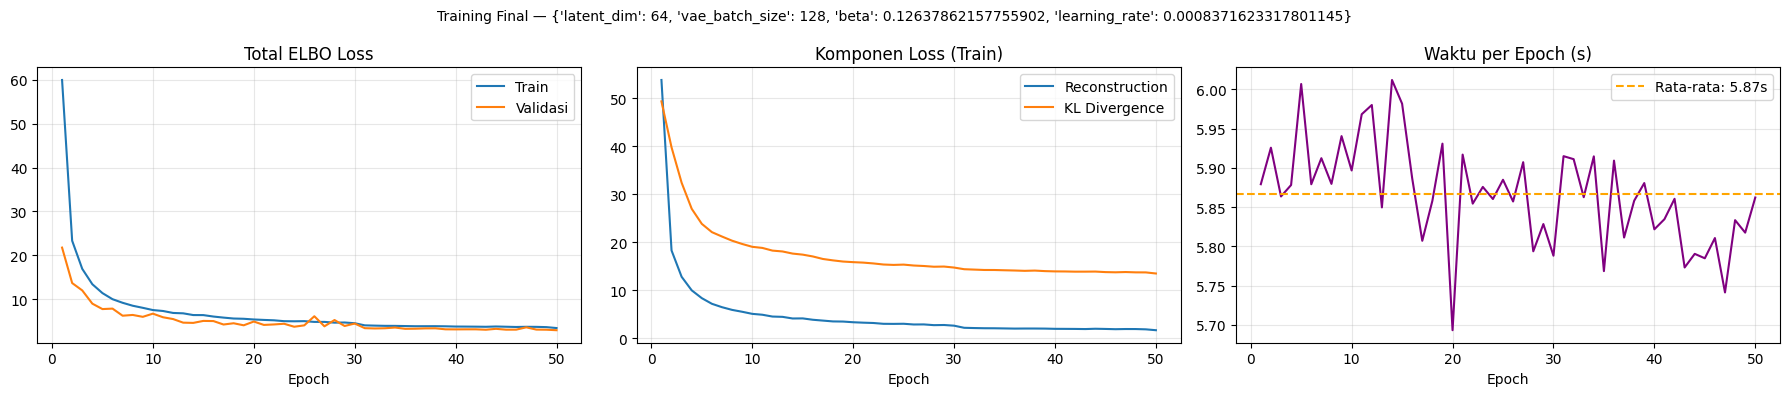

In [17]:
print(f"Training final — konfigurasi terbaik: {best_params}")
print(f"Training final memakai SELURUH data latih normal: {len(train_normal_scaled):,} sampel "
      f"(berbeda dari HP-search yang hanya memakai {len(hp_train_normal_scaled):,} sampel).")
BEST_DIR = os.path.join(CONFIG["output_dir"], "best_model")
os.makedirs(BEST_DIR, exist_ok=True)

vae, history, time_stats = train_vae(
    latent_dim  = best_params["latent_dim"],
    batch_size  = best_params["vae_batch_size"],
    beta        = best_params["beta"],
    lr          = best_params["learning_rate"],
    epochs      = CONFIG["vae_epochs"],
    save_dir    = BEST_DIR, label="best",
    train_data  = train_normal_scaled,   # <- 100% data latih (bukan subset HP-search)
)

h, rem = divmod(time_stats["total_train_sec"], 3600)
m_, s_ = divmod(rem, 60)
print(f"\n=== Metrik Waktu Latih ===")
print(f"  Total               : {int(h)}j {int(m_)}m {s_:.2f}s")
print(f"  Rata-rata per epoch : {time_stats['mean_epoch_sec']:.3f} s")
print(f"  Min per epoch       : {time_stats['min_epoch_sec']:.3f} s")
print(f"  Max per epoch       : {time_stats['max_epoch_sec']:.3f} s")
print(f"  Best val loss       : {time_stats['best_val_loss']:.6f}")

ep = range(1, len(history["train_loss"])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(ep, history["train_loss"], label="Train")
axes[0].plot(ep, history["val_loss"],   label="Validasi")
axes[0].set_title("Total ELBO Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ep, history["train_recon"], label="Reconstruction")
axes[1].plot(ep, history["train_kl"],    label="KL Divergence")
axes[1].set_title("Komponen Loss (Train)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(ep, history["epoch_time_s"], color="purple", lw=1.5)
axes[2].axhline(time_stats["mean_epoch_sec"], color="orange", ls="--",
                label=f"Rata-rata: {time_stats['mean_epoch_sec']:.2f}s")
axes[2].set_title("Waktu per Epoch (s)"); axes[2].set_xlabel("Epoch"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle(f"Training Final — {best_params}", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR,"learning_curve.png"), dpi=150)
plt.savefig(os.path.join(CONFIG["output_dir"],"learning_curve.png"), dpi=150)
plt.show()


## 11. Deteksi Anomali & Metrik Waktu Inferensi

Metrik inferensi: Latency per Sample, Throughput, FLOPs

In [18]:
def compute_reconstruction_losses(emb_array, model, batch_size=256):
    model.eval(); losses = []
    for i in range(0, len(emb_array), batch_size):
        batch = torch.tensor(emb_array[i:i+batch_size], dtype=torch.float32).to(DEVICE)
        loss  = model.reconstruction_loss(batch)
        losses.append(loss)
    return np.concatenate(losses)

def evt_threshold(losses, q=0.80, fpr_target=0.1):
    u = np.quantile(losses, q)
    exc = losses[losses > u] - u
    if len(exc) < 10: return float(np.percentile(losses, 99))
    shape, _, scale = genpareto.fit(exc, floc=0)
    print(f"  [EVT] xi={shape:.4f} sigma={scale:.4f} u={u:.6f}")
    return float(u + genpareto.ppf(1-fpr_target, shape, loc=0, scale=scale))

def measure_inference_metrics(emb_array, model, batch_size=256, n_warmup=3, n_repeat=5):
    model.eval(); n = len(emb_array)
    dummy = torch.tensor(emb_array[:min(batch_size, n)], dtype=torch.float32).to(DEVICE)
    for _ in range(n_warmup):
        with torch.no_grad(): model(dummy)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    elapsed = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        for i in range(0, n, batch_size):
            x = torch.tensor(emb_array[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            with torch.no_grad(): model(x)
        if DEVICE.type == "cuda": torch.cuda.synchronize()
        elapsed.append(time.perf_counter() - t0)
    total_s    = float(np.mean(elapsed))
    latency_ms = (total_s / n) * 1000
    throughput = n / total_s
    # FLOPs
    flops = None
    if FVCORE_AVAILABLE:
        try:
            d = torch.zeros(1, emb_array.shape[1]).to(DEVICE)
            fa = FlopCountAnalysis(model, d); fa.unsupported_ops_warnings(False)
            flops = fa.total()
        except Exception: pass
    if flops is None:
        flops = sum(2*p.numel() for n_, p in model.named_parameters() if "weight" in n_)
    return {"latency_ms_per_sample": round(latency_ms,4),
            "throughput_sample_per_s": round(throughput,2),
            "flops_per_sample": int(flops), "n_samples": n}

# ── Hitung losses per split ───────────────────────────────────────────────────
print("Menghitung reconstruction loss...")
train_losses_all = compute_reconstruction_losses(train_emb_scaled, vae)
val_losses_all   = compute_reconstruction_losses(val_emb_scaled,   vae)
test_losses_all  = compute_reconstruction_losses(test_emb_scaled,  vae)
train_normal_losses = train_losses_all[train_lbl == 0]

# ── Threshold (multi-persentil) ─────────────────────────────────────────────
# CONFIG["threshold_percentiles"] berisi daftar persentil yang akan dicoba
# (mis. [90, 95, 99]). Setiap persentil menghasilkan threshold & prediksi
# sendiri sehingga performanya bisa dibandingkan berdampingan dengan EVT/GPD.
PCT_LIST = CONFIG.get("threshold_percentiles", [CONFIG.get("threshold_percentile", 95)])

thresholds_pct = {}     # {90: nilai_threshold, 95: ..., 99: ...}
preds_pct_splits = {}   # {90: {"train":arr,"val":arr,"test":arr}, ...}

for pct in PCT_LIST:
    thr = np.percentile(train_normal_losses, pct)
    thresholds_pct[pct] = thr
    print(f"[Persentil] threshold (p{pct}): {thr:.6f}")
    preds_pct_splits[pct] = {
        "train": (train_losses_all > thr).astype(int),
        "val"  : (val_losses_all   > thr).astype(int),
        "test" : (test_losses_all  > thr).astype(int),
    }

# Alias untuk persentil "utama" (persentil pertama dalam daftar) — dipakai
# oleh sel-sel lama yang mengasumsikan satu threshold persentil tunggal
# (mis. bagian clustering & t-SNE di bawah).
MAIN_PCT      = PCT_LIST[0]
threshold_pct = thresholds_pct[MAIN_PCT]
train_preds_pct = preds_pct_splits[MAIN_PCT]["train"]
val_preds_pct   = preds_pct_splits[MAIN_PCT]["val"]
test_preds_pct  = preds_pct_splits[MAIN_PCT]["test"]

print("\n[EVT] menghitung threshold GPD...")
threshold_evt = evt_threshold(train_normal_losses)
print(f"[EVT] threshold: {threshold_evt:.6f}")

train_preds_evt = (train_losses_all > threshold_evt).astype(int)
val_preds_evt   = (val_losses_all   > threshold_evt).astype(int)
test_preds_evt  = (test_losses_all  > threshold_evt).astype(int)

# ── Inference metrics ─────────────────────────────────────────────────────────
print("\nMengukur metrik waktu inferensi pada data uji...")
inference_metrics = measure_inference_metrics(test_emb_scaled, vae)
print(f"\n=== Metrik Waktu Inferensi (n={inference_metrics['n_samples']:,}) ===")
print(f"  Latency per Sample   : {inference_metrics['latency_ms_per_sample']:.4f} ms")
print(f"  Throughput           : {inference_metrics['throughput_sample_per_s']:,.1f} sample/s")
print(f"  FLOPs per Sample     : {inference_metrics['flops_per_sample']:,}")

# Alias
all_losses_ordered = np.concatenate([train_losses_all, val_losses_all, test_losses_all])
known_lbl_ordered  = np.concatenate([train_lbl, val_lbl, test_lbl])
preds_pct = np.concatenate([train_preds_pct, val_preds_pct, test_preds_pct])
preds_evt = np.concatenate([train_preds_evt, val_preds_evt, test_preds_evt])

# Gabungan prediksi untuk SETIAP persentil (dipakai di evaluasi komparatif)
preds_pct_all_ordered = {
    pct: np.concatenate([preds_pct_splits[pct]["train"],
                          preds_pct_splits[pct]["val"],
                          preds_pct_splits[pct]["test"]])
    for pct in PCT_LIST
}

Menghitung reconstruction loss...
[Persentil] threshold (p90): 0.002975
[Persentil] threshold (p95): 0.005278
[Persentil] threshold (p99): 0.019555

[EVT] menghitung threshold GPD...
  [EVT] xi=0.7247 sigma=0.0016 u=0.001449
[EVT] threshold: 0.011026

Mengukur metrik waktu inferensi pada data uji...

=== Metrik Waktu Inferensi (n=41,798) ===
  Latency per Sample   : 0.0047 ms
  Throughput           : 210,764.0 sample/s
  FLOPs per Sample     : 1,142,272


### Distribusi Reconstruction Loss

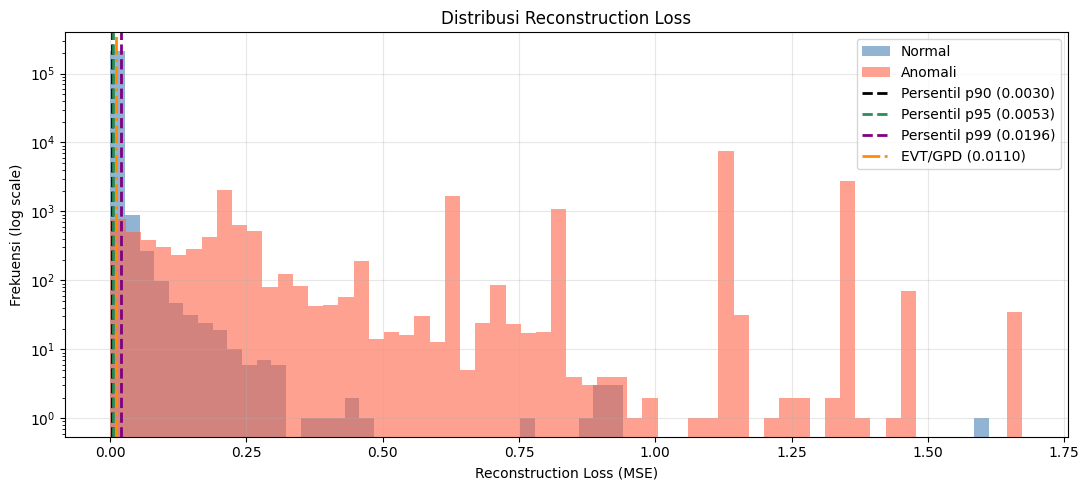

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(all_losses_ordered[known_lbl_ordered==0], bins=60, alpha=0.6,
        color="steelblue", label="Normal", log=True)
ax.hist(all_losses_ordered[known_lbl_ordered==1], bins=60, alpha=0.6,
        color="tomato",    label="Anomali", log=True)
_pct_colors = ["black", "seagreen", "purple", "brown", "gray"]
for _i, _pct in enumerate(PCT_LIST):
    ax.axvline(thresholds_pct[_pct], color=_pct_colors[_i % len(_pct_colors)], ls="--", lw=2,
               label=f"Persentil p{_pct} ({thresholds_pct[_pct]:.4f})")
ax.axvline(threshold_evt, color="darkorange", ls="-.", lw=2,
           label=f"EVT/GPD ({threshold_evt:.4f})")
ax.set_xlabel("Reconstruction Loss (MSE)")
ax.set_ylabel("Frekuensi (log scale)")
ax.set_title("Distribusi Reconstruction Loss")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR, "loss_distribution.png"), dpi=150)
plt.savefig(os.path.join(CONFIG["output_dir"], "loss_distribution.png"), dpi=150)
plt.show()

## 12. Evaluasi Komparatif — Train / Validasi / Uji  x  Persentil / EVT

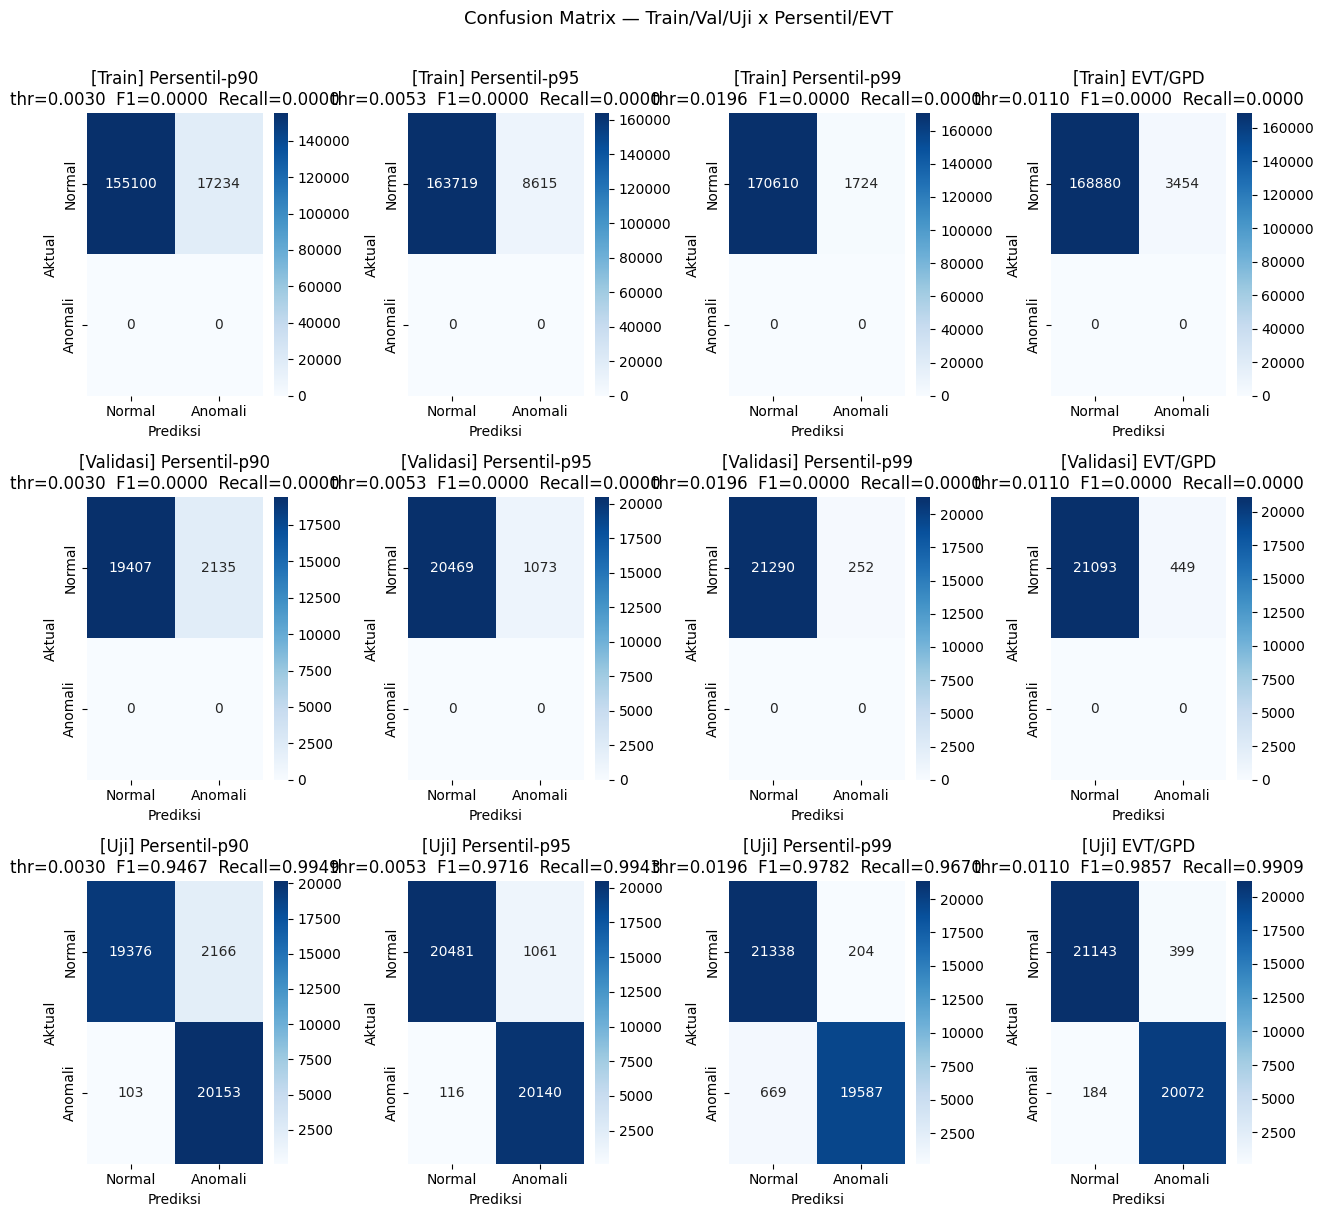


 Report — Persentil-p90 [Train]
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95    172334
     Anomali       0.00      0.00      0.00         0

    accuracy                           0.90    172334
   macro avg       0.50      0.45      0.47    172334
weighted avg       1.00      0.90      0.95    172334


 Report — Persentil-p95 [Train]
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    172334
     Anomali       0.00      0.00      0.00         0

    accuracy                           0.95    172334
   macro avg       0.50      0.48      0.49    172334
weighted avg       1.00      0.95      0.97    172334


 Report — Persentil-p99 [Train]
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    172334
     Anomali       0.00      0.00      0.00         0

    accuracy                           0.99    172334
   macro avg       0.50      

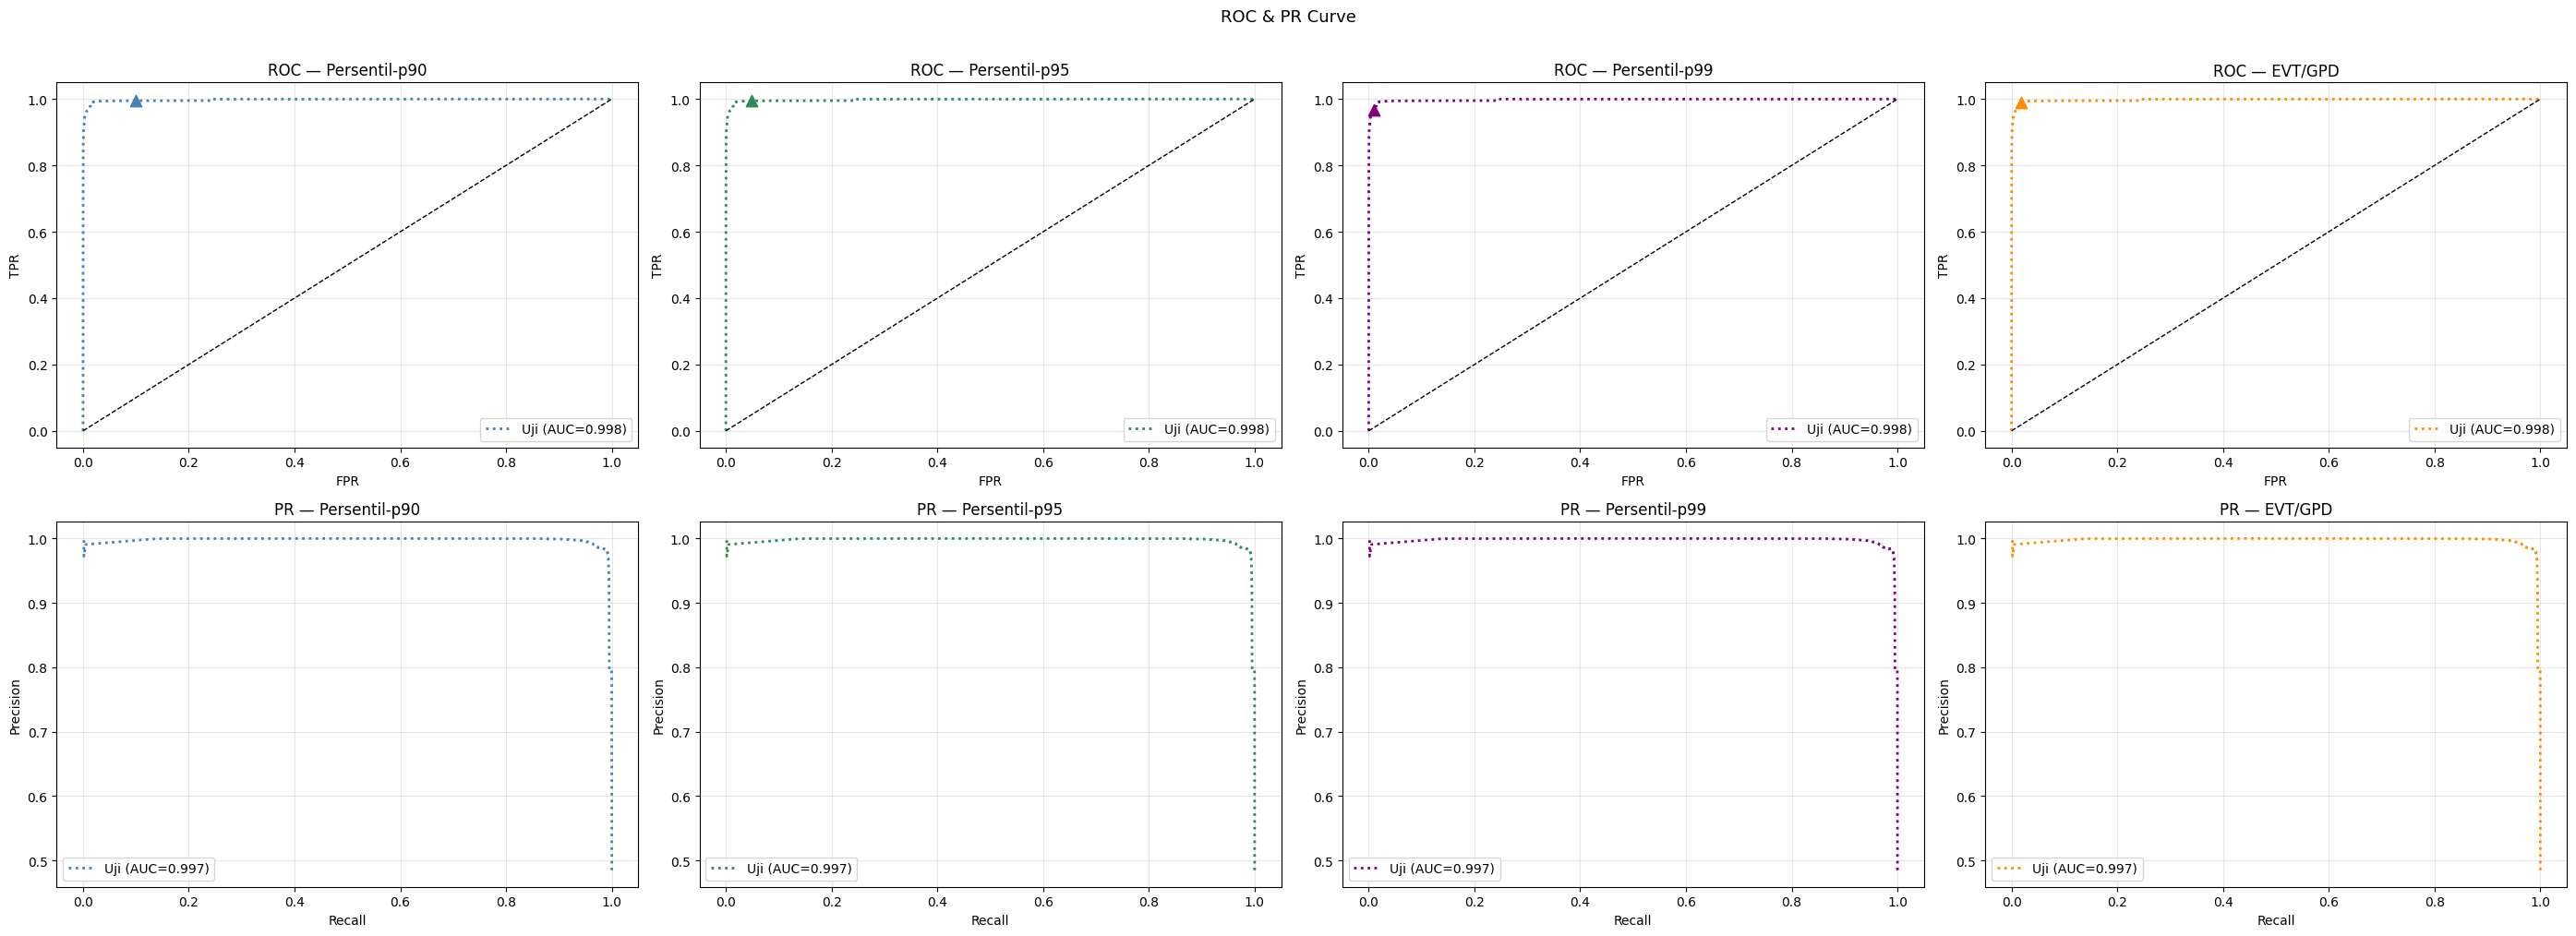


 PERBANDINGAN METRIK — Train / Validasi / Uji  x  p90 / p95 / p99 / EVT
  Metrik             p90-Tra     p95-Tra     p99-Tra     EVT-Tra     p90-Val     p95-Val     p99-Val     EVT-Val     p90-Uji     p95-Uji     p99-Uji     EVT-Uji
----------------------------------------------------------------------------------------------------------------------------------------------------
  Accuracy               0.9        0.95        0.99        0.98      0.9009      0.9502      0.9883      0.9792      0.9457      0.9718      0.9791      0.9861
  Precision              0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0       0.903        0.95      0.9897      0.9805
  Recall                 0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0      0.9949      0.9943       0.967      0.9909
  F1                     0.0         0.0         0.0         0.0         0.0         0.0         0.0         0.0      0.9467      0.97

In [20]:
splits = {
    "Train"   : {"y_true":train_lbl, "y_score":train_losses_all,
                 "preds_evt":train_preds_evt,
                 **{f"preds_pct_{pct}": preds_pct_splits[pct]["train"] for pct in PCT_LIST}},
    "Validasi": {"y_true":val_lbl,   "y_score":val_losses_all,
                 "preds_evt":val_preds_evt,
                 **{f"preds_pct_{pct}": preds_pct_splits[pct]["val"] for pct in PCT_LIST}},
    "Uji"     : {"y_true":test_lbl,  "y_score":test_losses_all,
                 "preds_evt":test_preds_evt,
                 **{f"preds_pct_{pct}": preds_pct_splits[pct]["test"] for pct in PCT_LIST}},
}

# Setiap persentil (mis. p90, p95, p99) diperlakukan sebagai "metode" tersendiri
# sehingga performanya bisa dibandingkan berdampingan dengan EVT/GPD.
_pct_palette = ["steelblue", "seagreen", "purple", "brown", "gray"]
methods_cfg = {
    f"Persentil-p{pct}": {"key": f"preds_pct_{pct}", "threshold": thresholds_pct[pct],
                           "color": _pct_palette[_i % len(_pct_palette)]}
    for _i, pct in enumerate(PCT_LIST)
}
methods_cfg["EVT/GPD"] = {"key":"preds_evt","threshold":threshold_evt,"color":"darkorange"}

def compute_split_metrics(y_true, y_pred, y_score):
    has2 = len(np.unique(y_true)) > 1
    roc  = roc_auc_score(y_true, y_score) if has2 else float("nan")
    p, r, _ = precision_recall_curve(y_true, y_score) if has2 else ([0],[0],[0])
    pr   = auc(r, p) if has2 else float("nan")
    return {"accuracy": round(accuracy_score(y_true, y_pred),4),
            "precision": round(precision_score(y_true,y_pred,zero_division=0),4),
            "recall":    round(recall_score(y_true,y_pred,zero_division=0),4),
            "f1":        round(f1_score(y_true,y_pred,zero_division=0),4),
            "roc_auc":   round(roc,4), "pr_auc": round(pr,4)}

all_metrics = {sn:{mn:compute_split_metrics(sp["y_true"],sp[methods_cfg[mn]["key"]],sp["y_score"])
                   for mn in methods_cfg} for sn, sp in splits.items()}

# ── Confusion Matrix 3x2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(len(splits), len(methods_cfg), figsize=(13, 4*len(splits)))
for row, (sn, sp) in enumerate(splits.items()):
    for col, (mn, mc) in enumerate(methods_cfg.items()):
        ax = axes[row][col]
        cm = confusion_matrix(sp["y_true"], sp[mc["key"]])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Normal","Anomali"], yticklabels=["Normal","Anomali"], ax=ax)
        ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
        m = all_metrics[sn][mn]
        ax.set_title(f"[{sn}] {mn}\nthr={mc['threshold']:.4f}  F1={m['f1']:.4f}  Recall={m['recall']:.4f}")
plt.suptitle("Confusion Matrix — Train/Val/Uji x Persentil/EVT", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR,"confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.savefig(os.path.join(CONFIG["output_dir"],"confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Classification Reports ────────────────────────────────────────────────────
for sn, sp in splits.items():
    for mn, mc in methods_cfg.items():
        print(f"\n{'='*50}")
        print(f" Report — {mn} [{sn}]")
        print(f"{'='*50}")
        print(classification_report(sp["y_true"],sp[mc["key"]],
                                    target_names=["Normal","Anomali"], zero_division=0))

# ── ROC & PR Curves ───────────────────────────────────────────────────────────
# Jumlah kolom mengikuti jumlah metode di methods_cfg (p90, p95, p99, EVT/GPD, ...)
# secara dinamis, agar tidak error saat jumlah persentil ditambah/dikurangi.
split_styles = {"Train":("-","o"),"Validasi":("--","s"),"Uji":(":","^")}
n_methods = len(methods_cfg)
fig, axes = plt.subplots(2, n_methods, figsize=(7*n_methods, 10), squeeze=False)
for col, (mn, mc) in enumerate(methods_cfg.items()):
    for sn, sp in splits.items():
        yt, ys = sp["y_true"], sp["y_score"]
        if len(np.unique(yt)) < 2: continue
        fpr, tpr, _ = roc_curve(yt, ys)
        prec, rec, _ = precision_recall_curve(yt, ys)
        rv = roc_auc_score(yt, ys); pv = auc(rec, prec)
        op_fpr = ((ys>mc["threshold"])&(yt==0)).sum()/max((yt==0).sum(),1)
        op_tpr = ((ys>mc["threshold"])&(yt==1)).sum()/max((yt==1).sum(),1)
        ls, mk = split_styles[sn]
        axes[0][col].plot(fpr,tpr, lw=2, ls=ls, color=mc["color"], label=f"{sn} (AUC={rv:.3f})")
        axes[0][col].scatter([op_fpr],[op_tpr], color=mc["color"], marker=mk, s=80, zorder=5)
        axes[1][col].plot(rec,prec, lw=2, ls=ls, color=mc["color"], label=f"{sn} (AUC={pv:.3f})")
    axes[0][col].plot([0,1],[0,1],"k--",lw=1)
    axes[0][col].set(xlabel="FPR",ylabel="TPR",title=f"ROC — {mn}"); axes[0][col].legend(); axes[0][col].grid(True, alpha=0.3)
    axes[1][col].set(xlabel="Recall",ylabel="Precision",title=f"PR — {mn}"); axes[1][col].legend(); axes[1][col].grid(True, alpha=0.3)
plt.suptitle("ROC & PR Curve", fontsize=13, y=1.01); plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR,"roc_pr.png"), dpi=150, bbox_inches="tight")
plt.savefig(os.path.join(CONFIG["output_dir"],"roc_pr.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Tabel Ringkas ─────────────────────────────────────────────────────────────
# Label kolom singkat & jelas per metode: p90/p95/p99/EVT (bukan mn[:3] yang
# membuat semua persentil terlihat sama "Per").
def _short_method_label(mn):
    return mn.replace("Persentil-p", "p").replace("EVT/GPD", "EVT")

metric_keys = [("accuracy","Accuracy"),("precision","Precision"),
               ("recall","Recall"),("f1","F1"),("roc_auc","ROC-AUC"),("pr_auc","PR-AUC")]
snames = list(splits.keys()); cw = 11
total_w = 16 + cw * len(snames) * len(methods_cfg)
print(f"\n{'='*total_w}")
print(" PERBANDINGAN METRIK — Train / Validasi / Uji  x  " + " / ".join(_short_method_label(m) for m in methods_cfg))
print(f"{'='*total_w}")
hdr = f"  {'Metrik':<14}"
for sn in snames:
    for mn in methods_cfg: hdr += f" {f'{_short_method_label(mn)}-{sn[:3]}':>{cw}}"
print(hdr); print("-"*total_w)
for key, lbl in metric_keys:
    row = f"  {lbl:<14}"
    for sn in snames:
        for mn in methods_cfg: row += f" {all_metrics[sn][mn][key]:>{cw}}"
    print(row)
print("="*total_w)

# ── Ringkasan Per Metode (rata-rata, agar mudah bandingkan p90 vs p95 vs p99 vs EVT)
print("\n=== Ringkasan Per Metode (split Uji) ===")
for mn in methods_cfg:
    m = all_metrics["Uji"][mn]
    print(f"  {_short_method_label(mn):<8} | thr={methods_cfg[mn]['threshold']:.4f}  "
          f"Acc={m['accuracy']:.4f}  Prec={m['precision']:.4f}  Rec={m['recall']:.4f}  "
          f"F1={m['f1']:.4f}  ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}")

# Alias
y_true  = known_lbl_ordered; y_pred = preds_pct; y_score = all_losses_ordered
roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true))>1 else float("nan")
prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
pr_auc  = auc(rec_c, prec_c)

In [21]:
# (Sel lama telah digantikan)

## 13. Evaluasi Clustering (Ruang Laten VAE)

In [22]:
all_emb_ordered = np.vstack([train_emb_scaled, val_emb_scaled, test_emb_scaled])
vae.eval(); latent_list = []
with torch.no_grad():
    for i in range(0, len(all_emb_ordered), 256):
        batch = torch.tensor(all_emb_ordered[i:i+256], dtype=torch.float32).to(DEVICE)
        mu, _ = vae.encoder(batch)
        latent_list.append(mu.cpu().numpy())
latent_all = np.vstack(latent_list)
print(f"Latent shape: {latent_all.shape}")

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
max_sil = 5000
if len(latent_all) > max_sil:
    idx_sil = np.random.choice(len(latent_all), max_sil, replace=False)
    sil_score = silhouette_score(latent_all[idx_sil], y_pred[idx_sil])
else:
    sil_score = silhouette_score(latent_all, y_pred)
print(f"\n=== Metrik Clustering ===")
print(f"  ARI       : {ari:.4f}")
print(f"  NMI       : {nmi:.4f}")
print(f"  Silhouette: {sil_score:.4f}")

Latent shape: (235674, 64)

=== Metrik Clustering ===
  ARI       : 0.5326
  NMI       : 0.4392
  Silhouette: 0.3416


### Visualisasi Ruang Laten (t-SNE)

Menjalankan t-SNE...


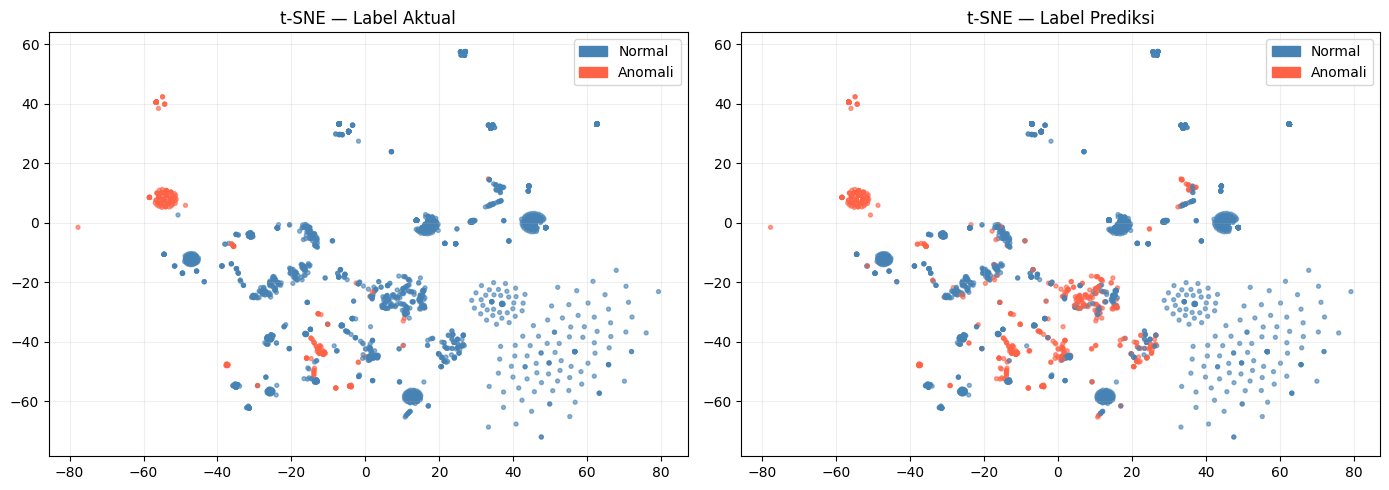

In [23]:
# t-SNE pada subset (maksimum 3000 titik agar cepat)
max_vis = 3000 # len(latent_all)
if len(latent_all) > max_vis:
    idx_vis  = np.random.choice(len(latent_all), max_vis, replace=False)
    lat_vis  = latent_all[idx_vis]
    lbl_vis  = y_true[idx_vis]
    pred_vis = y_pred[idx_vis]
else:
    lat_vis, lbl_vis, pred_vis = latent_all, y_true, y_pred

print("Menjalankan t-SNE...")
tsne = TSNE(n_components=2, random_state=CONFIG["seed"], perplexity=30, max_iter=1000)
proj = tsne.fit_transform(lat_vis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label sebenarnya
colors = ["steelblue" if l == 0 else "tomato" for l in lbl_vis]
axes[0].scatter(proj[:, 0], proj[:, 1], c=colors, s=8, alpha=0.6)
axes[0].set_title("t-SNE — Label Aktual")
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color="steelblue", label="Normal"),
                          Patch(color="tomato",    label="Anomali")])
axes[0].grid(True, alpha=0.2)

# Prediksi
colors_pred = ["steelblue" if p == 0 else "tomato" for p in pred_vis]
axes[1].scatter(proj[:, 0], proj[:, 1], c=colors_pred, s=8, alpha=0.6)
axes[1].set_title("t-SNE — Label Prediksi")
axes[1].legend(handles=[Patch(color="steelblue", label="Normal"),
                          Patch(color="tomato",    label="Anomali")])
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "tsne.png"), dpi=150)
plt.show()

## 14. Ringkasan Hasil & Penyimpanan Artefak


 RINGKASAN HASIL EVALUASI
  dataset                                 : BGL
  windowing                               : sliding(20)
  split                                   : n_train_normal=172334 val_ratio=0.5 (train/val=normal only, test=normal_sisa+anomali)
  n_train                                 : 172334
  n_val                                   : 21542
  n_test                                  : 41798
  hp_search_frac                          : 1
  n_train_hp_search                       : 172334
  n_train_normal_full                     : 172334
  best_latent_dim                         : 64
  best_vae_batch_size                     : 128
  best_beta                               : 0.126379
  best_learning_rate                      : 0.00083716
  embedder_train_total_sec                : 1768.505
  embedder_train_mean_ms_per_sample       : 7.504
  embedder_train_throughput_sps           : 133.26
  embedder_infer_latency_ms               : 5.9973
  embedder_infer_throughput_sps 

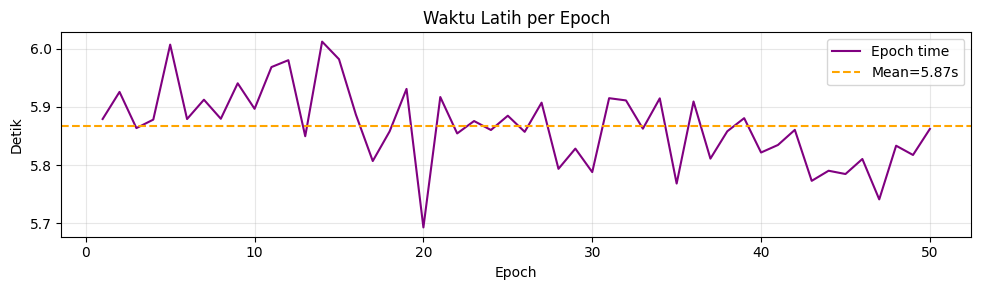


Struktur output (/kaggle/working/outputs):
outputs/
  confusion_matrix.png
  embedder_time_stats.json
  embeddings.npy
  epoch_time.png
  hp_search_results.csv
  labels.npy
  learning_curve.png
  loss_distribution.png
  metrics_table.csv
  roc_pr.png
  summary.json
  timing_metrics.csv
  tsne.png
  best_model/
    confusion_matrix.png
    epoch_time.png
    learning_curve.png
    loss_distribution.png
    metrics_table.csv
    roc_pr.png
    summary.json
    timing_metrics.csv
    vae_best.pt
  hp_trials/
    trial_000/
      learning_curve.png
      trial_summary.json
      vae_trial_000.pt
    trial_001/
      learning_curve.png
      trial_summary.json
      vae_trial_001.pt
    trial_002/
      learning_curve.png
      trial_summary.json
      vae_trial_002.pt
    trial_003/
      learning_curve.png
      trial_summary.json
      vae_trial_003.pt
    trial_004/
      learning_curve.png
      trial_summary.json
      vae_trial_004.pt
    trial_005/
      learning_curve.png
      tr

In [24]:
summary = {
    "dataset"       : CONFIG["dataset_name"],
    "windowing"     : "block-ID" if CONFIG["dataset_name"]=="HDFS" else f"sliding({CONFIG['window_size']})",
    "split"         : f"n_train_normal={CONFIG['n_train_normal']} val_ratio={CONFIG['val_ratio']} (train/val=normal only, test=normal_sisa+anomali)",
    "n_train"       : int(len(train_lbl)),
    "n_val"         : int(len(val_lbl)),
    "n_test"        : int(len(test_lbl)),
    "hp_search_frac"        : CONFIG["hp_search_frac"],
    "n_train_hp_search"     : int(len(hp_train_normal_scaled)),
    "n_train_normal_full"   : int(len(train_normal_scaled)),
    "best_latent_dim"     : best_params["latent_dim"],
    "best_vae_batch_size" : best_params["vae_batch_size"],
    "best_beta"           : round(best_params["beta"], 6),
    "best_learning_rate"  : round(best_params["learning_rate"], 8),
    "embedder_train_total_sec"         : embedder_train_time_stats["total_sec"],
    "embedder_train_mean_ms_per_sample": round(embedder_train_time_stats["mean_sec_per_sample"]*1000, 4),
    "embedder_train_throughput_sps"    : embedder_train_time_stats["throughput_sample_per_s"],
    "embedder_infer_latency_ms"        : embedder_infer_time_stats["latency_ms_per_sample"],
    "embedder_infer_throughput_sps"    : embedder_infer_time_stats["throughput_sample_per_s"],
    "embedder_infer_flops"             : embedder_infer_time_stats["flops_per_sample"],
    "train_total_sec"     : time_stats["total_train_sec"],
    "train_mean_epoch_sec": time_stats["mean_epoch_sec"],
    "train_min_epoch_sec" : time_stats["min_epoch_sec"],
    "train_max_epoch_sec" : time_stats["max_epoch_sec"],
    "infer_latency_ms"    : inference_metrics["latency_ms_per_sample"],
    "infer_throughput_sps": inference_metrics["throughput_sample_per_s"],
    "infer_flops"         : inference_metrics["flops_per_sample"],
    "threshold_evt"       : round(float(threshold_evt), 6),
    **{f"threshold_p{pct}": round(float(thresholds_pct[pct]), 6) for pct in PCT_LIST},
    # Metrik untuk SETIAP persentil (p90, p95, p99, ...) x Train/Val/Uji
    **{f"[Pct-p{pct}-Train] {k}": v
       for pct in PCT_LIST for k, v in all_metrics["Train"][f"Persentil-p{pct}"].items()},
    **{f"[Pct-p{pct}-Val]   {k}": v
       for pct in PCT_LIST for k, v in all_metrics["Validasi"][f"Persentil-p{pct}"].items()},
    **{f"[Pct-p{pct}-Test]  {k}": v
       for pct in PCT_LIST for k, v in all_metrics["Uji"][f"Persentil-p{pct}"].items()},
    **{f"[EVT-Train] {k}": v for k,v in all_metrics["Train"]["EVT/GPD"].items()},
    **{f"[EVT-Val]   {k}": v for k,v in all_metrics["Validasi"]["EVT/GPD"].items()},
    **{f"[EVT-Test]  {k}": v for k,v in all_metrics["Uji"]["EVT/GPD"].items()},
    "ari"       : round(ari, 4),
    "nmi"       : round(nmi, 4),
    "silhouette": round(sil_score, 4),
}

print("\n" + "="*60)
print(" RINGKASAN HASIL EVALUASI")
print("="*60)
for k, v in summary.items():
    print(f"  {k:<40}: {v}")
print("="*60)

# ── JSON summary ──────────────────────────────────────────────────────────────
for p in [os.path.join(BEST_DIR,"summary.json"), os.path.join(CONFIG["output_dir"],"summary.json")]:
    with open(p,"w") as f: json.dump(summary, f, indent=2, default=str)
print(f"\nRingkasan JSON: {BEST_DIR}/summary.json")

# ── Metrics CSV (per split x method) ─────────────────────────────────────────
rows = [{"split":sn,"method":mn,**all_metrics[sn][mn],"threshold":round(float(methods_cfg[mn]["threshold"]),6)}
        for sn in splits for mn in methods_cfg]
metrics_df = pd.DataFrame(rows)
for p in [os.path.join(BEST_DIR,"metrics_table.csv"), os.path.join(CONFIG["output_dir"],"metrics_table.csv")]:
    metrics_df.to_csv(p, index=False)
print(f"Tabel metrik CSV: {BEST_DIR}/metrics_table.csv")

# ── Timing CSV (VAE + Embedder, termasuk FLOPs) ───────────────────────────────
timing_rows = [
    {"category":"embedder_train","metric":"total_sec",              "value":embedder_train_time_stats["total_sec"]},
    {"category":"embedder_train","metric":"mean_ms_per_sample",     "value":round(embedder_train_time_stats["mean_sec_per_sample"]*1000,4)},
    {"category":"embedder_train","metric":"throughput_sample_per_s","value":embedder_train_time_stats["throughput_sample_per_s"]},
    {"category":"embedder_infer","metric":"latency_ms_per_sample",  "value":embedder_infer_time_stats["latency_ms_per_sample"]},
    {"category":"embedder_infer","metric":"throughput_sample_per_s","value":embedder_infer_time_stats["throughput_sample_per_s"]},
    {"category":"embedder_infer","metric":"flops_per_sample",       "value":embedder_infer_time_stats["flops_per_sample"]},
    {"category":"vae_train","metric":"total_sec",          "value":time_stats["total_train_sec"]},
    {"category":"vae_train","metric":"mean_epoch_sec",     "value":time_stats["mean_epoch_sec"]},
    {"category":"vae_train","metric":"min_epoch_sec",      "value":time_stats["min_epoch_sec"]},
    {"category":"vae_train","metric":"max_epoch_sec",      "value":time_stats["max_epoch_sec"]},
    {"category":"vae_infer","metric":"latency_ms_per_sample",   "value":inference_metrics["latency_ms_per_sample"]},
    {"category":"vae_infer","metric":"throughput_sample_per_s", "value":inference_metrics["throughput_sample_per_s"]},
    {"category":"vae_infer","metric":"flops_per_sample",        "value":inference_metrics["flops_per_sample"]},
]
timing_df = pd.DataFrame(timing_rows)
for p in [os.path.join(BEST_DIR,"timing_metrics.csv"), os.path.join(CONFIG["output_dir"],"timing_metrics.csv")]:
    timing_df.to_csv(p, index=False)
print(f"Metrik waktu CSV  : {BEST_DIR}/timing_metrics.csv")

# ── Epoch time plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,3))
ax.plot(range(1, len(history["epoch_time_s"])+1), history["epoch_time_s"], lw=1.5, color="purple", label="Epoch time")
ax.axhline(time_stats["mean_epoch_sec"], color="orange", ls="--", label=f"Mean={time_stats['mean_epoch_sec']:.2f}s")
ax.set_xlabel("Epoch"); ax.set_ylabel("Detik"); ax.set_title("Waktu Latih per Epoch")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(BEST_DIR,"epoch_time.png"), dpi=150)
plt.savefig(os.path.join(CONFIG["output_dir"],"epoch_time.png"), dpi=150)
plt.show()

# ── Struktur folder ───────────────────────────────────────────────────────────
print(f"\nStruktur output ({CONFIG['output_dir']}):")
for root, dirs, files in os.walk(CONFIG["output_dir"]):
    dirs.sort(); files.sort()
    level = root.replace(CONFIG["output_dir"],"").count(os.sep)
    print("  "*level + os.path.basename(root) + "/")
    for fname in files: print("  "*(level+1) + fname)


## 14. Inferensi pada Data Baru
Gunakan sel berikut untuk mendeteksi anomali pada log baru tanpa melatih ulang.

In [25]:
# def predict_new_log(log_file, dataset_name, embedder, scaler, vae,
#                     threshold, window_size=100, hdfs_label_file=None):
#     df_new, hlm = parse_logs(log_file, dataset_name, hdfs_label_file=hdfs_label_file)
#     wins_new = create_windows_hdfs(df_new, hlm) if dataset_name=="HDFS" else create_windows(df_new, window_size)
#     emb_new, lbl_new = generate_embeddings(wins_new, embedder, CONFIG["bert_batch_size"])
#     emb_s  = scaler.transform(emb_new)
#     losses = compute_reconstruction_losses(emb_s, vae)
#     preds  = (losses > threshold).astype(int)
#     inf_m  = measure_inference_metrics(emb_s, vae)
#     seq_ids = [w.get("block_id", i) for i, w in enumerate(wins_new)]
#     return pd.DataFrame({"sequence_id":seq_ids,"label_true":lbl_new,
#                          "label_pred":preds,"recon_loss":losses}), inf_m
print("Fungsi inferensi siap digunakan.")

Fungsi inferensi siap digunakan.


In [26]:
!tar -cvzf /kaggle/working/outputs_compressed.tar.gz -C /kaggle/working/outputs .

./
./hp_trials/
./hp_trials/trial_023/
./hp_trials/trial_023/learning_curve.png
./hp_trials/trial_023/vae_trial_023.pt
./hp_trials/trial_023/trial_summary.json
./hp_trials/trial_025/
./hp_trials/trial_025/vae_trial_025.pt
./hp_trials/trial_025/learning_curve.png
./hp_trials/trial_025/trial_summary.json
./hp_trials/trial_020/
./hp_trials/trial_020/learning_curve.png
./hp_trials/trial_020/vae_trial_020.pt
./hp_trials/trial_020/trial_summary.json
./hp_trials/trial_005/
./hp_trials/trial_005/vae_trial_005.pt
./hp_trials/trial_005/learning_curve.png
./hp_trials/trial_005/trial_summary.json
./hp_trials/trial_014/
./hp_trials/trial_014/learning_curve.png
./hp_trials/trial_014/vae_trial_014.pt
./hp_trials/trial_014/trial_summary.json
./hp_trials/trial_007/
./hp_trials/trial_007/learning_curve.png
./hp_trials/trial_007/vae_trial_007.pt
./hp_trials/trial_007/trial_summary.json
./hp_trials/trial_004/
./hp_trials/trial_004/learning_curve.png
./hp_trials/trial_004/vae_trial_004.pt
./hp_trials/trial

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Menghitung panjang token:   0%|          | 0/235674 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (521 > 512). Running this sequence through the model will result in indexing errors


=== Statistik Jumlah Baris Log per Block ===
  Min    : 20
  Median : 20
  Mean   : 20.0
  P90    : 20
  P99    : 20
  Max    : 20

=== Statistik Panjang Token (sebelum truncation) ===
  Min    : 41
  Median : 161
  Mean   : 272.4
  P90    : 681
  P99    : 1221
  Max    : 3065

[!] Dengan bert_max_length=512:
    13.1% block AKAN TERPOTONG (token asli > 512)
    - Normal  : median=175 token, P90=741, 12.8% terpotong (n=215,418)
    - Anomali : median=121 token, P90=601, 15.8% terpotong (n=20,256)


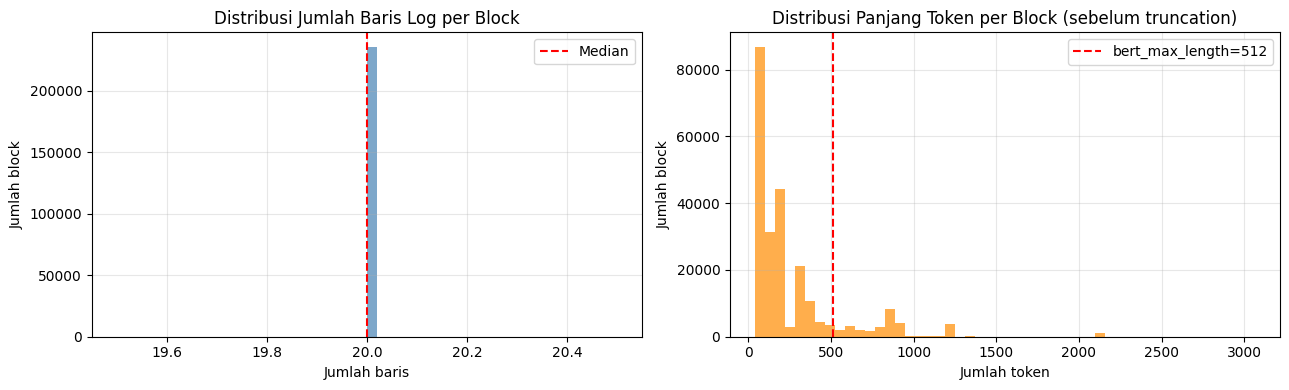


[SARAN] Untuk menangkap ~95% block secara utuh, set bert_max_length ke sekitar 512 (maks 512 untuk DistilBERT).


In [27]:
diag_tokenizer = DistilBertTokenizer.from_pretrained(CONFIG["bert_model"])

# Gabungkan template persis seperti di generate_embeddings()
diag_texts = [" [SEP] ".join(w["texts"]) for w in windows]

# Hitung jumlah token TANPA truncation, agar tahu panjang aslinya
token_lengths = [
    len(diag_tokenizer.encode(t, add_special_tokens=True))
    for t in tqdm(diag_texts, desc="Menghitung panjang token")
]
token_lengths = np.array(token_lengths)

# Jumlah baris log mentah per block (sebelum di-join)
n_lines_per_block = np.array([len(w["texts"]) for w in windows])

print("=== Statistik Jumlah Baris Log per Block ===")
print(f"  Min    : {n_lines_per_block.min()}")
print(f"  Median : {np.median(n_lines_per_block):.0f}")
print(f"  Mean   : {n_lines_per_block.mean():.1f}")
print(f"  P90    : {np.percentile(n_lines_per_block, 90):.0f}")
print(f"  P99    : {np.percentile(n_lines_per_block, 99):.0f}")
print(f"  Max    : {n_lines_per_block.max()}")

print("\n=== Statistik Panjang Token (sebelum truncation) ===")
print(f"  Min    : {token_lengths.min()}")
print(f"  Median : {np.median(token_lengths):.0f}")
print(f"  Mean   : {token_lengths.mean():.1f}")
print(f"  P90    : {np.percentile(token_lengths, 90):.0f}")
print(f"  P99    : {np.percentile(token_lengths, 99):.0f}")
print(f"  Max    : {token_lengths.max()}")

current_max_len = CONFIG["bert_max_length"]
pct_truncated = (token_lengths > current_max_len).mean() * 100
print(f"\n[!] Dengan bert_max_length={current_max_len}:")
print(f"    {pct_truncated:.1f}% block AKAN TERPOTONG (token asli > {current_max_len})")

# Breakdown truncation berdasarkan label (normal vs anomali) — PENTING
labels_arr = np.array([w["label"] for w in windows])
for lbl_val, lbl_name in [(0, "Normal"), (1, "Anomali")]:
    mask = labels_arr == lbl_val
    if mask.sum() == 0:
        continue
    sub = token_lengths[mask]
    pct_trunc_sub = (sub > current_max_len).mean() * 100
    print(f"    - {lbl_name:8s}: median={np.median(sub):.0f} token, "
          f"P90={np.percentile(sub,90):.0f}, "
          f"{pct_trunc_sub:.1f}% terpotong (n={mask.sum():,})")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(n_lines_per_block, bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(np.median(n_lines_per_block), color="red", ls="--", label="Median")
axes[0].set_title("Distribusi Jumlah Baris Log per Block")
axes[0].set_xlabel("Jumlah baris"); axes[0].set_ylabel("Jumlah block")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(token_lengths, bins=50, color="darkorange", alpha=0.7)
axes[1].axvline(current_max_len, color="red", ls="--",
                 label=f"bert_max_length={current_max_len}")
axes[1].set_title("Distribusi Panjang Token per Block (sebelum truncation)")
axes[1].set_xlabel("Jumlah token"); axes[1].set_ylabel("Jumlah block")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "diag_token_length.png"), dpi=150)
plt.show()

# Rekomendasi otomatis nilai bert_max_length
suggested_len = int(np.percentile(token_lengths, 95))
suggested_len = min(512, ((suggested_len // 8) + 1) * 8)  # bulatkan ke atas, cap di 512
print(f"\n[SARAN] Untuk menangkap ~95% block secara utuh, "
      f"set bert_max_length ke sekitar {suggested_len} (maks 512 untuk DistilBERT).")